# ID5059: Flight Delays
Investigating flight delays from several airports near New York over the course of one year. Fit at least two machine learning models and prepare a summary report for the Director of Operations of a major airport. Further information on the attributes of the nycflights13 dataset can be found [here](https://openflights.org/data.php).

**Research Questions:**
1. Can we predict, before a flight has departed, whether it will arrive late?
2. Which factors are most correlated with delays?

In [525]:
# Importing the required dependencies
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# For the pipeline
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# For modelling
from sklearn.linear_model import LogisticRegression, SGDClassifier # Good baseline models
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier # More robust models

# For hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# For model evaluation
from sklearn.metrics import (
    classification_report, 
    confusion_matrix,   
    f1_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay
)

## Creating the Training and Test Set

We are working with supervised data since we have the arr_delay for each flight. We will want to have an even split of arr_delay across the test/validation/training sets.

We will consider this a binary classification task (is a flight late or not) and use arr_delay to create a classification label is_delayed.

We should then examine the .csv files to look for which features may be useful to predict which flights will be delayed. Once we have a big table of everything we want to include, we should split the data into train / validation / test using a split. We will need a validation set to compare the different models we build before picking one to fine tune.

**Plan:**
1. Create a label is_delayed to classify whether a particular observation (row in flights.csv) is delayed or not
    * Are there any NA values for arr_delay? If so, what does that mean?
    * Decide whether to replace NA values or remove them
2. Check the distribution of delayed flights
3. Create analytical base table (ABT) with chosen high-level data
    * Is there any CSV data which is less useful which we can exclude?
4. Perform the train / validation / test split
5. Verify that the % of delays in the training set matches the % of the delays in the test set

### 1. Create new classifier is_delayed

Work on a copy of the data for reproducibility.

In [526]:
# Locate the file, read it in, and observe
flights_file_name = "../data/flights.csv"
flights_data = pd.read_csv(flights_file_name)
flights_data.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01 05:00:00
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01 05:00:00
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01 05:00:00
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01 05:00:00
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01 06:00:00


In [527]:
# Check observations (shape[0]) and features (shape[1])
flights_data.shape

(336776, 19)

In [528]:
# Check for NA values
flights_data.isna().sum()

# 9430/336776 = 2.8% of the data is missing for arr_delay
# An NA arr_delay can't mean early (which is a negative number) or on time (which = 0)
# So we will assume it means the flight was cancelled
# We will drop these rows since it's small enough to drop without losing too much info


year                 0
month                0
day                  0
dep_time          8255
sched_dep_time       0
dep_delay         8255
arr_time          8713
sched_arr_time       0
arr_delay         9430
carrier              0
flight               0
tailnum           2512
origin               0
dest                 0
air_time          9430
distance             0
hour                 0
minute               0
time_hour            0
dtype: int64

In [529]:
# Drop the rows where arr_delay is NA since we can't create a label from this
flights_clean = flights_data.dropna(subset=['arr_delay']).copy()
flights_delay_not_null = flights_data['arr_delay'].notnull().sum()

# Sanity check all rows with NA arr_delay have been dropped
if flights_delay_not_null == flights_clean.shape[0]:
    print(f"Rows before drop: {flights_data.shape[0]}")
    print(f"Rows dropped: {flights_data.isna().sum()['arr_delay']}")
    print(f"Rows remaining: {flights_clean.shape[0]}")

Rows before drop: 336776
Rows dropped: 9430
Rows remaining: 327346


In [530]:
# We will assume that a flight is delayed if it arrives 15 minutes or more after its scheduled arrival time
# 1 = delayed, 0 otherwise
flights_clean['is_delayed'] = (flights_clean['arr_delay'] >= 15).astype(int)

# Sanity check is_delayed is categorising correctly
flights_clean[['arr_delay', 'is_delayed']].head(10)

,arr_delay,is_delayed
0,11.0,0
1,20.0,1
2,33.0,1
3,-18.0,0
4,-25.0,0
5,12.0,0
6,19.0,1
7,-14.0,0
8,-8.0,0
9,8.0,0


### 2. Check the distribution of delayed flights

If the dataset is imbalanced (eg 20% delays and 80% on-time) we will need to do a stratified split to ensure the train and test sets have similar proportions of delayed/on-time data.

In [531]:
# Check the proportion of delayed flights
print(flights_clean['is_delayed'].value_counts(normalize=True))

# The dataset is imbalanced (~25% flights are delayed) so we should use stratified splitting
# to ensure the proportion of delayed flights in the train / validation / test sets are similar

is_delayed
0    0.755305
1    0.244695
Name: proportion, dtype: float64


### 3. Create ABT with chosen high-level data

Common causes of aviation delays may be the schedule (time of flight or month), the operator (airline or origin airport), or the environment (weather conditions or distance).

After inspecting the .csv files, airports.csv and planes.csv seem like they would have low additional value versus the expense of including them in the ABT. We could explore if there's a relationship between older plane machinery (planes.csv) and flight delays, but this is not as obvious as the aforementioned assumptions (schedule, operator, and weather).

Therefore, we will use:
- **airlines.csv**
- **flights.csv**
- **weather.csv**

This will usefully simplify the model, but it may also narrow the scope of the data so the final model may be oblivious to some potential causes of delays. For the scope of this project, we will drop planes.csv and airports.csv to allow for deeper exploration of data which we assume is more likely to be important.

If I had more time I may explore geographical data (eg northbound vs southbound delays) or plane age data. 

In [532]:
# We need to merge flights.csv with airlines (for names) and weather (for weather info)

# Locate the weather file, read it in, and observe
weather_file_name = "../data/weather.csv"
weather_data = pd.read_csv(weather_file_name)
weather_data.head()

,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
0,EWR,2013,1,1,1,39.02,26.06,59.37,270.0,10.35702,NaN,0.0,1012.0,10.0,2013-01-01T06:00:00Z
1,EWR,2013,1,1,2,39.02,26.96,61.63,250.0,8.05546,NaN,0.0,1012.3,10.0,2013-01-01T07:00:00Z
2,EWR,2013,1,1,3,39.02,28.04,64.43,240.0,11.50780,NaN,0.0,1012.5,10.0,2013-01-01T08:00:00Z
3,EWR,2013,1,1,4,39.92,28.04,62.21,250.0,12.65858,NaN,0.0,1012.2,10.0,2013-01-01T09:00:00Z
4,EWR,2013,1,1,5,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0,2013-01-01T10:00:00Z


In [533]:
# Check the features in more detail to identify potential features to merge with flights.csv
weather_data.info()

# Origin, year, month, day, and hour have no null entries (could be primary key)

<class 'pandas.DataFrame'>
RangeIndex: 26115 entries, 0 to 26114
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   origin      26115 non-null  str    
 1   year        26115 non-null  int64  
 2   month       26115 non-null  int64  
 3   day         26115 non-null  int64  
 4   hour        26115 non-null  int64  
 5   temp        26114 non-null  float64
 6   dewp        26114 non-null  float64
 7   humid       26114 non-null  float64
 8   wind_dir    25655 non-null  float64
 9   wind_speed  26111 non-null  float64
 10  wind_gust   5337 non-null   float64
 11  precip      26115 non-null  float64
 12  pressure    23386 non-null  float64
 13  visib       26115 non-null  float64
 14  time_hour   26115 non-null  str    
dtypes: float64(9), int64(4), str(2)
memory usage: 3.0 MB


In [534]:
# Check if the combination of origin, year, month, day, and hour is unique in weather.csv
is_unique = weather_data.groupby(['origin', 'year', 'month', 'day', 'hour']).size().max() == 1
print(f"Is the keyset unique: {is_unique}")

# It's not, so identify all rows that have a duplicate combination of our keys
keys = ['origin', 'year', 'month', 'day', 'hour']
duplicates = weather_data[weather_data.duplicated(subset=keys, keep=False)]

print(f"Number of duplicate rows: {duplicates.shape[0]} / {weather_data.shape[0]}")

# Sort them so the duplicates are next to each other
duplicates.sort_values(by=keys).head(10)

# Twice a year there are two entries for each airport at the same hour on the same day
# We will assume this is due to clocks going forward / back for daylight savings time

Is the keyset unique: False
Number of duplicate rows: 6 / 26115


,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
7318,EWR,2013,11,3,1,51.98,39.02,61.15,310.0,6.90468,NaN,0.0,1009.8,10.0,2013-11-03T05:00:00Z
7319,EWR,2013,11,3,1,50.00,39.02,65.80,290.0,5.75390,NaN,0.0,1010.5,10.0,2013-11-03T06:00:00Z
16023,JFK,2013,11,3,1,53.96,37.94,54.51,320.0,9.20624,NaN,0.0,1009.8,10.0,2013-11-03T05:00:00Z
16024,JFK,2013,11,3,1,51.98,37.94,58.62,310.0,6.90468,NaN,0.0,1010.5,10.0,2013-11-03T06:00:00Z
24729,LGA,2013,11,3,1,55.04,39.02,54.67,330.0,9.20624,NaN,0.0,1009.3,10.0,2013-11-03T05:00:00Z
24730,LGA,2013,11,3,1,53.96,39.92,58.89,310.0,8.05546,NaN,0.0,1010.2,10.0,2013-11-03T06:00:00Z


In [535]:
# Both entries have weather info for the same time so we will calculate a simple mean of numeric values
weather_data_unique = weather_data.groupby(keys).mean(numeric_only=True).reset_index()

# Verify after taking the mean that the keyset is now unique
is_unique = weather_data_unique.groupby(['origin', 'year', 'month', 'day', 'hour']).size().max() == 1
print(f"Is the keyset unique: {is_unique}")

# Sanity check the new dataframe looks as expected
weather_data_unique.head(10)

Is the keyset unique: True


,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
0,EWR,2013,1,1,1,39.02,26.06,59.37,270.0,10.35702,NaN,0.0,1012.0,10.0
1,EWR,2013,1,1,2,39.02,26.96,61.63,250.0,8.05546,NaN,0.0,1012.3,10.0
2,EWR,2013,1,1,3,39.02,28.04,64.43,240.0,11.50780,NaN,0.0,1012.5,10.0
3,EWR,2013,1,1,4,39.92,28.04,62.21,250.0,12.65858,NaN,0.0,1012.2,10.0
4,EWR,2013,1,1,5,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0
5,EWR,2013,1,1,6,37.94,28.04,67.21,240.0,11.50780,NaN,0.0,1012.4,10.0
6,EWR,2013,1,1,7,39.02,28.04,64.43,240.0,14.96014,NaN,0.0,1012.2,10.0
7,EWR,2013,1,1,8,39.92,28.04,62.21,250.0,10.35702,NaN,0.0,1012.2,10.0
8,EWR,2013,1,1,9,39.92,28.04,62.21,260.0,14.96014,NaN,0.0,1012.7,10.0
9,EWR,2013,1,1,10,41.00,28.04,59.65,260.0,13.80936,NaN,0.0,1012.4,10.0


In [536]:
# Check the features in more detail to be sure
weather_data_unique.info()

# Number of rows has reduced from 26115 to 26112 after removing duplicates (3 pairs merged)
# So this is as expected

<class 'pandas.DataFrame'>
RangeIndex: 26112 entries, 0 to 26111
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   origin      26112 non-null  str    
 1   year        26112 non-null  int64  
 2   month       26112 non-null  int64  
 3   day         26112 non-null  int64  
 4   hour        26112 non-null  int64  
 5   temp        26111 non-null  float64
 6   dewp        26111 non-null  float64
 7   humid       26111 non-null  float64
 8   wind_dir    25652 non-null  float64
 9   wind_speed  26108 non-null  float64
 10  wind_gust   5337 non-null   float64
 11  precip      26112 non-null  float64
 12  pressure    23383 non-null  float64
 13  visib       26112 non-null  float64
dtypes: float64(9), int64(4), str(1)
memory usage: 2.8 MB


In [537]:
# Perform a left join using the chosen keys, keep all flight info but adding new weather info
flights_weather = flights_clean.merge(weather_data_unique, on=keys, how='left')

# Sanity check the merge worked as expected
flights_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 327346 entries, 0 to 327345
Data columns (total 29 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            327346 non-null  int64  
 1   month           327346 non-null  int64  
 2   day             327346 non-null  int64  
 3   dep_time        327346 non-null  float64
 4   sched_dep_time  327346 non-null  int64  
 5   dep_delay       327346 non-null  float64
 6   arr_time        327346 non-null  float64
 7   sched_arr_time  327346 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         327346 non-null  str    
 10  flight          327346 non-null  int64  
 11  tailnum         327346 non-null  str    
 12  origin          327346 non-null  str    
 13  dest            327346 non-null  str    
 14  air_time        327346 non-null  float64
 15  distance        327346 non-null  int64  
 16  hour            327346 non-null  int64  
 17  minute          32734

In [538]:
# Check if carrier is null in flights_weather before joining
flights_weather['carrier'].isna().sum()

np.int64(0)

In [539]:
# Locate the airlines file, read it in, and observe
airlines_file_name = "../data/airlines.csv"
airlines_data = pd.read_csv(airlines_file_name)
airlines_data.head(20)

# Airlines.csv is a complete list of all carriers and their names

,carrier,name
0,9E,Endeavor Air Inc.
1,AA,American Airlines Inc.
2,AS,Alaska Airlines Inc.
3,B6,JetBlue Airways
4,DL,Delta Air Lines Inc.
5,EV,ExpressJet Airlines Inc.
6,F9,Frontier Airlines Inc.
7,FL,AirTran Airways Corporation
8,HA,Hawaiian Airlines Inc.
9,MQ,Envoy Air


In [540]:
# Perform a left join on carrier to add airline names in case we want it for presenting analysis later
flights_weather_airlines = flights_weather.merge(airlines_data, on='carrier', how='left')

# Sanity check the merged dataframe is what we expect before doing any splitting
flights_weather_airlines.info()

<class 'pandas.DataFrame'>
RangeIndex: 327346 entries, 0 to 327345
Data columns (total 30 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            327346 non-null  int64  
 1   month           327346 non-null  int64  
 2   day             327346 non-null  int64  
 3   dep_time        327346 non-null  float64
 4   sched_dep_time  327346 non-null  int64  
 5   dep_delay       327346 non-null  float64
 6   arr_time        327346 non-null  float64
 7   sched_arr_time  327346 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         327346 non-null  str    
 10  flight          327346 non-null  int64  
 11  tailnum         327346 non-null  str    
 12  origin          327346 non-null  str    
 13  dest            327346 non-null  str    
 14  air_time        327346 non-null  float64
 15  distance        327346 non-null  int64  
 16  hour            327346 non-null  int64  
 17  minute          32734

### 4. Perform train / test split

Bin the arr_delay (currently a numerical) into categories to ensure the train and test set get an equal share of on time, slightly late and majorly late flights

<Axes: xlabel='arr_delay', ylabel='count'>

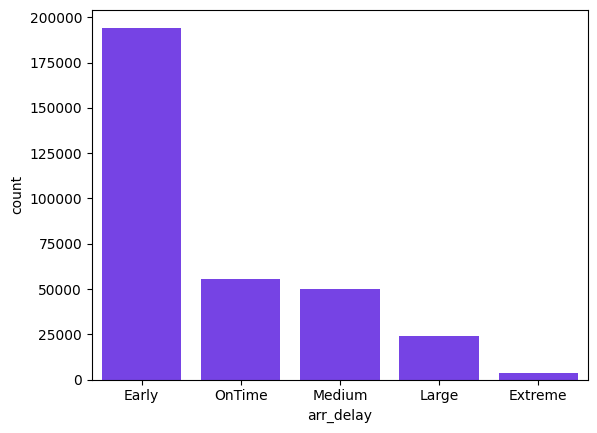

In [541]:
# Create the bins to split arr_delay into categories for stratificatoin
strat_bins = pd.cut(
    flights_weather_airlines['arr_delay'],
    bins=[-np.inf, 0, 15, 60, 180, np.inf],
    labels=['Early', 'OnTime', 'Medium', 'Large', 'Extreme']
)

# View the distribution of the bins
sns.countplot(x=strat_bins, color='#6c28ff')

# This confirms the distribution is imbalanced so we should use stratified sampling

In [542]:
# We will use a stratified shuffle split using the bins we create
# We will do one split to get the (training & validation) group and the test group
shuffled_data = StratifiedShuffleSplit(
    n_splits=1, # We are only splitting once for a train & test set
    test_size=0.2, # Test set will be 20% of the data
    random_state=42 # Set seed to maintain split and reproducibility (Geron always uses 42)
)

# Create indexes based on the 5 bins
[(train_val_index, test_index)] = shuffled_data.split(
    flights_weather_airlines,
    strat_bins
)

# Create the train_val and test sets using the calculated indexes
flights_train_val_raw = flights_weather_airlines.iloc[train_val_index].copy()
flights_test_raw = flights_weather_airlines.iloc[test_index].copy()

Create a validation set which will be used to train the model which performed best on the training set.

In [543]:
# Make new bins with the dimensions for the (training & validation) set
train_val_strat_bins = pd.cut(
    flights_train_val_raw['arr_delay'],
    bins=[-np.inf, 0, 15, 60, 180, np.inf],
    labels=['Early', 'OnTime', 'Medium', 'Large', 'Extreme']
)

shuffled_data_validation = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.25, # 25% of the training set (80%) is 20%
    random_state=42
)

[(train_index, val_index)] = shuffled_data.split(
    flights_train_val_raw,
    train_val_strat_bins
)

# Use the new indexes to split the (training & validation) set into the training and validation set
flights_train_raw = flights_train_val_raw.iloc[train_index].copy()
flights_validation_raw = flights_train_val_raw.iloc[val_index].copy()

### 5. Verify that the Training & Test Set have similar delay distributions

  delay_category     train  validation      test
0          Early  0.593690    0.593688  0.593692
1         OnTime  0.169160    0.169161  0.169161
2         Medium  0.152258    0.152264  0.152253
3          Large  0.073155    0.073144  0.073148
4        Extreme  0.011737    0.011742  0.011746


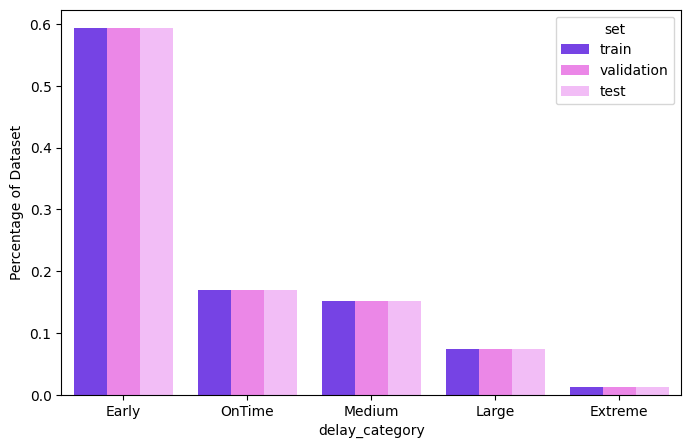

In [544]:
# Get the distribution of the bins in each set to check stratification worked
train_dist = train_val_strat_bins.iloc[train_index].value_counts(normalize=True)
val_dist = train_val_strat_bins.iloc[val_index].value_counts(normalize=True)
test_dist = strat_bins.iloc[test_index].value_counts(normalize=True)

# Combine and reset index to compare the distributions across train / validation /test sets
dist_df = pd.DataFrame({'train': train_dist, 'validation': val_dist, 'test': test_dist}).reset_index()
dist_df.columns = ['delay_category', 'train', 'validation','test']

# Check the raw distribution numbers
print(dist_df)

# Plot for easy comparison
dist_melted = dist_df.melt(id_vars='delay_category', var_name='set', value_name='percentage')

plt.figure(figsize=(8,5))
sns.barplot(data=dist_melted, x='delay_category', y='percentage', hue='set', palette=['#6c28ff','#fc76f7', "#fab4ff"])
plt.ylabel('Percentage of Dataset')
plt.show()

## Data Wrangling

From this point forward, this is on the **TRAINING SET ONLY**. We will use a copy of the training set to freely explore the data before manipulating the actual training data.


**Plan:**
1. Read in the data
2. Data Cleaning
    * Check data types
    * Convert any incorrect columns
    * Check for missing values
3. Data Exploration
    * Look for unique identifiers
    * Look at feature distributions
    * Look for any order in the data
    * Look for relationships with response
    * Check correlations
4. Revised Data Cleaning
    * Make decisions based off of data exploration
5. (Exploring) Feature Engineering
    * Are there any numerical features which may be more useful as categories?

### 1. Read in the data

In [545]:
# All data exploration will be done on a copy of the training set to freely explore the data
# The final pipeline based off of the exploration will use the actual training set
flights_train_copy = flights_train_raw.copy()

flights_train_copy.info()

<class 'pandas.DataFrame'>
Index: 209500 entries, 59674 to 186079
Data columns (total 30 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            209500 non-null  int64  
 1   month           209500 non-null  int64  
 2   day             209500 non-null  int64  
 3   dep_time        209500 non-null  float64
 4   sched_dep_time  209500 non-null  int64  
 5   dep_delay       209500 non-null  float64
 6   arr_time        209500 non-null  float64
 7   sched_arr_time  209500 non-null  int64  
 8   arr_delay       209500 non-null  float64
 9   carrier         209500 non-null  str    
 10  flight          209500 non-null  int64  
 11  tailnum         209500 non-null  str    
 12  origin          209500 non-null  str    
 13  dest            209500 non-null  str    
 14  air_time        209500 non-null  float64
 15  distance        209500 non-null  int64  
 16  hour            209500 non-null  int64  
 17  minute          209500

In [546]:
flights_train_copy.shape
# There are 261876 observations and 30 features

(209500, 30)

### 2. Data Cleaning

In [547]:
# Check the data types of features to see if they match expectations
flights_train_copy.dtypes.to_frame(name='Data Type')

# It seems like month, carrier (airline code), origin, dest, and name (of airline) should be categorical,
# but they are numerical or object types currently so we will convert these

,Data Type
year,int64
month,int64
day,int64
dep_time,float64
sched_dep_time,int64
dep_delay,float64
arr_time,float64
sched_arr_time,int64
arr_delay,float64
carrier,str


Converting column types in the data to the correct types.

In [548]:
# List out the columns to change type into a category
category_columns = ["month", "carrier", "origin", "dest", "hour", "name"]

# Convert the types
flights_train_copy[category_columns] = flights_train_copy[category_columns].astype('category')

# Check the data types have been updated correctly
flights_train_copy.dtypes.to_frame(name='Updated Data Type')

,Updated Data Type
year,int64
month,category
day,int64
dep_time,float64
sched_dep_time,int64
dep_delay,float64
arr_time,float64
sched_arr_time,int64
arr_delay,float64
carrier,category


Checking for missing values.

In [549]:
# Converting to a dataframe for readability
flights_train_copy.isna().sum(axis=0).to_frame(name='# of Missing Values')

,# of Missing Values
year,0
month,0
day,0
dep_time,0
sched_dep_time,0
dep_delay,0
arr_time,0
sched_arr_time,0
arr_delay,0
carrier,0


We can see that out of the training set's 261876 entries, there is a lot of weather data missing. `wind_gust` and `pressure` have the most missing data, so we will drop these now.

We also need to consider:
* `temp` (1230)
* `dewp` (1230)
* `humid` (1230)
* `wind_dir` (7646)
* `wind_speed` (1282)
* `precip` (1216)
* `visib` (1216)

`wind_speed`, `precip`, and `visib` seem like they might be crucial so we will potentially keep these. But it would be better to investigate the data more before making decisions on any of these.

In [550]:
# Drop wind_gust and pressure from the training set now
flights_train_copy = flights_train_copy.drop(columns=['wind_gust', 'pressure'])

# Sanity check they've been dropped correctly
flights_train_copy.info()

<class 'pandas.DataFrame'>
Index: 209500 entries, 59674 to 186079
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   year            209500 non-null  int64   
 1   month           209500 non-null  category
 2   day             209500 non-null  int64   
 3   dep_time        209500 non-null  float64 
 4   sched_dep_time  209500 non-null  int64   
 5   dep_delay       209500 non-null  float64 
 6   arr_time        209500 non-null  float64 
 7   sched_arr_time  209500 non-null  int64   
 8   arr_delay       209500 non-null  float64 
 9   carrier         209500 non-null  category
 10  flight          209500 non-null  int64   
 11  tailnum         209500 non-null  str     
 12  origin          209500 non-null  category
 13  dest            209500 non-null  category
 14  air_time        209500 non-null  float64 
 15  distance        209500 non-null  int64   
 16  hour            209500 non-null  category
 17  min

### 3. Data Exploration

The aim of this is to find out for each feature:
* Name, description, meaning
* Type (categorical, numerical, text)
* Missing values
* Noisiness and type of noise
* Usefulness!
* Distribution
* Is it a unique identifier?

Some of this information can be found on the [nycflights13 webpage](https://openflights.org/data.php) or for this specific dataset in `../data/dictionary.md`.

In [551]:
flights_train_copy.nunique().to_frame(name='# of Unique Values')

# Remember there are 261876 rows
# From this we can see that no two features have the same number of unique values
# Other numeric columns don't have unique values either (they are much smaller than 261876)
# So we don't need to exclude anything based on this

,# of Unique Values
year,1
month,12
day,31
dep_time,1297
sched_dep_time,1014
dep_delay,484
arr_time,1402
sched_arr_time,1156
arr_delay,534
carrier,16


We will plot the distribution for each feature to see if there are any patterns.

Continuous features we will look at are:
* temp
* dewp
* humid
* wind_speed
* precip
* visib
* distance

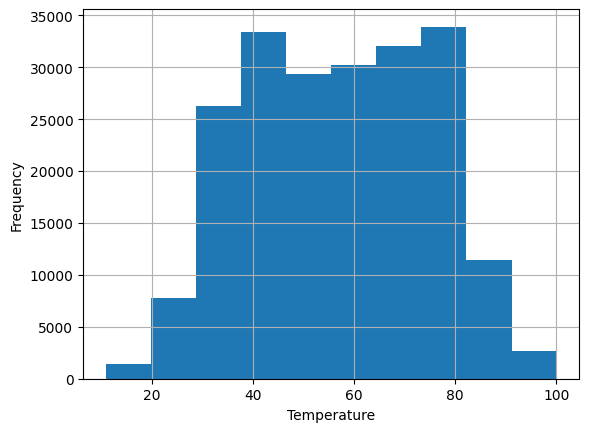

In [552]:
flights_train_copy['temp'].hist()

plt.ylabel('Frequency')
plt.xlabel('Temperature')
plt.show()
# This distribution is roughly normal so we could use a median imputation strategy for missing values here

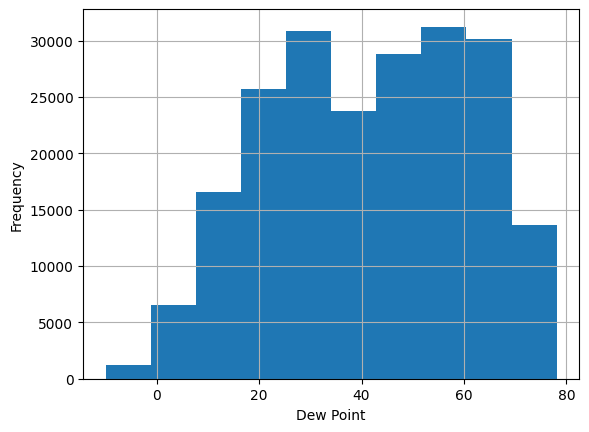

In [553]:
flights_train_copy['dewp'].hist()

plt.ylabel('Frequency')
plt.xlabel('Dew Point')
plt.show()
# This distribution is also roughly normal so we will use a median imputation strategy

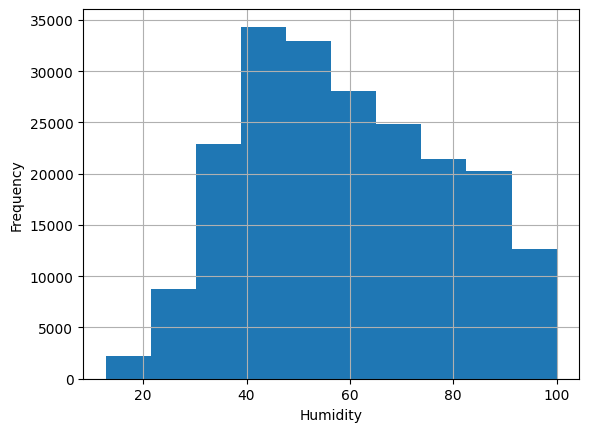

In [554]:
flights_train_copy['humid'].hist()

plt.ylabel('Frequency')
plt.xlabel('Humidity')
plt.show()
# This distribution is also roughly normal so we will use a median imputation strategy

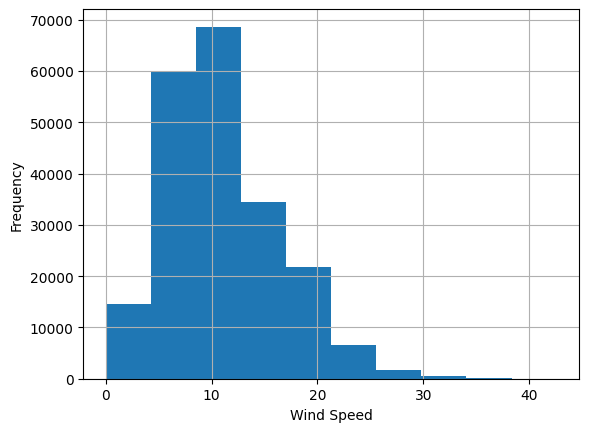

In [555]:
flights_train_copy['wind_speed'].hist()

plt.ylabel('Frequency')
plt.xlabel('Wind Speed')
plt.show()
# This distribution is roughly normal but right skewed
# We will still use a median imputation strategy for missing values here
# Because the mean would be pulled up by the long tails on the left

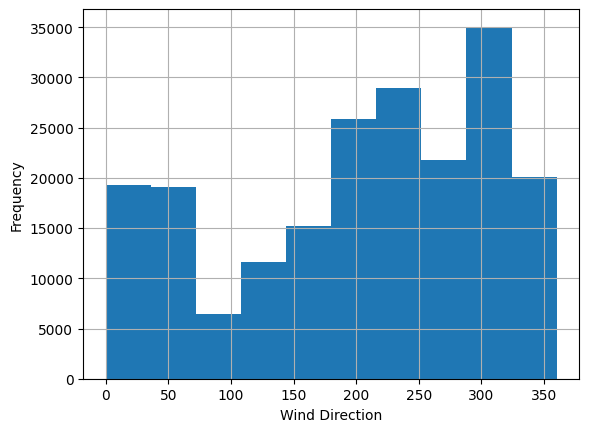

In [556]:
flights_train_copy['wind_dir'].hist()

plt.ylabel('Frequency')
plt.xlabel('Wind Direction')
plt.show()

# There doesn't seem to be a clear distribution here
# Would probably end up dropping this depending on its correlation with the response

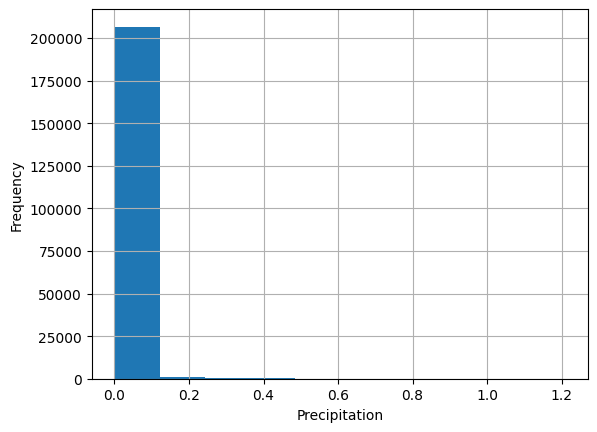

In [557]:
flights_train_copy['precip'].hist()

plt.ylabel('Frequency')
plt.xlabel('Precipitation')
plt.show()
# Here it is suitable to fill in missing values with the mode (0)
# Since the vast majority of values are 0 so the mode is more representative
# But we should still note the graph plots up to 1.2 so there are some non-zero values to be aware of

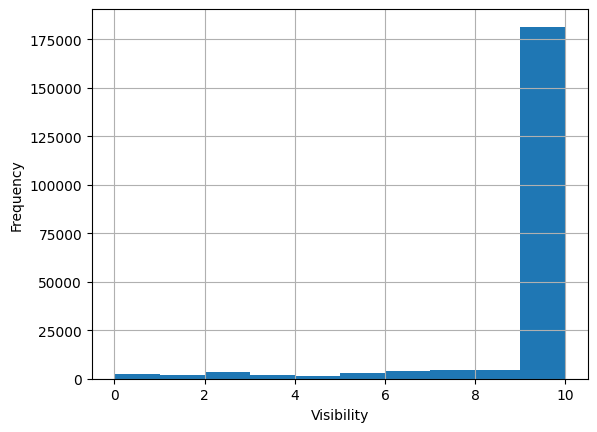

In [558]:
flights_train_copy['visib'].hist()

plt.ylabel('Frequency')
plt.xlabel('Visibility')
plt.show()
# Again, missing values should probably be filled in with the mode (10)

Mean distance: 1048.9366443914082
Median distance: 888.0


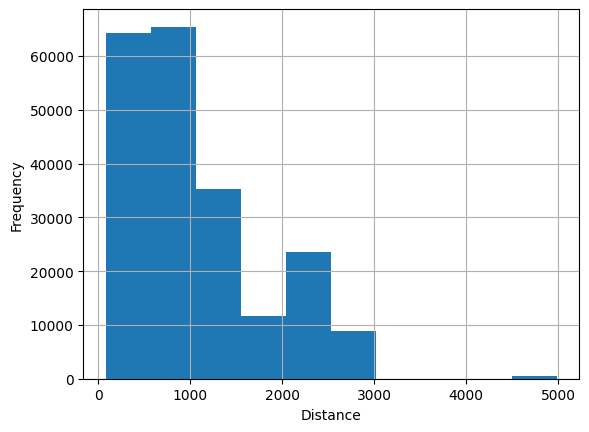

In [559]:
flights_train_copy['distance'].hist()

mean_distance = flights_train_copy['distance'].mean()
median_distance = flights_train_copy['distance'].median()

print(f"Mean distance: {mean_distance}"
      f"\nMedian distance: {median_distance}")

plt.ylabel('Frequency')
plt.xlabel('Distance')
plt.show()
# This distribution is right skewed with long tails
# We will also use a median imputation strategy for missing values here
# Since the mean would be pulled up by the long tails

Categorical features to look at are:
* origin
* dest
* carrier / name
* month
* hour

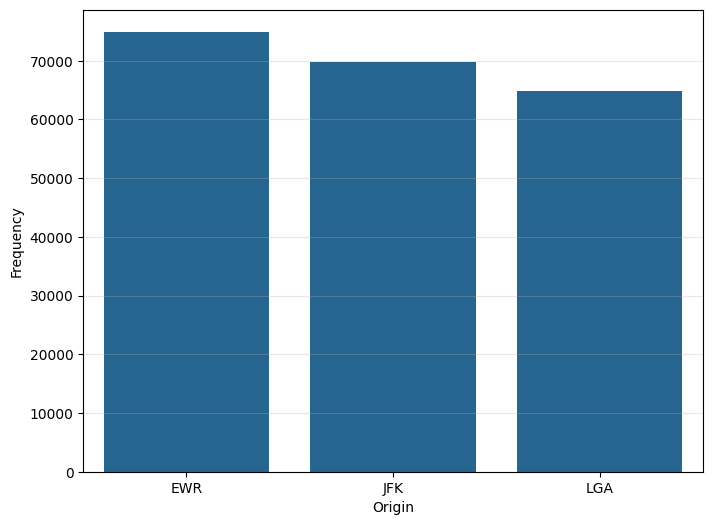

In [560]:
# Using a simple .hist() caused misalignment of bars over categories, so using a countplot instead
plt.figure(figsize=(8, 6))
sns.countplot(data=flights_train_copy, x='origin', color="#1469A1")

plt.ylabel('Frequency')
plt.xlabel('Origin')
plt.grid(axis='y', alpha=0.3)
plt.show()
# EWR operates the most flights, followed by JFK and then LGA

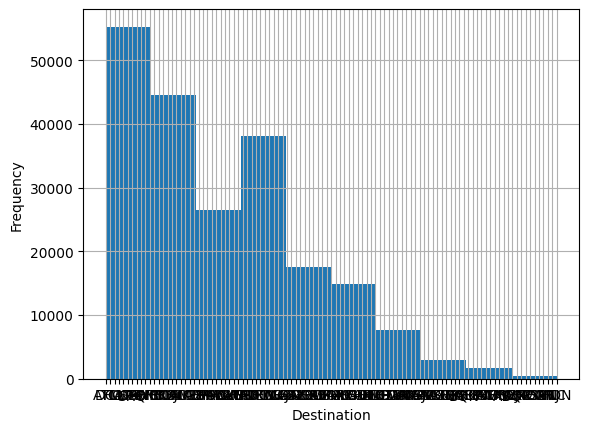

In [561]:
flights_train_copy['dest'].hist()

plt.ylabel('Frequency')
plt.xlabel('Destination')
plt.show()
# There's no "obvious" destination that we would want to impute missing values with
# Potentially come up with an "unknown" category for missing values here

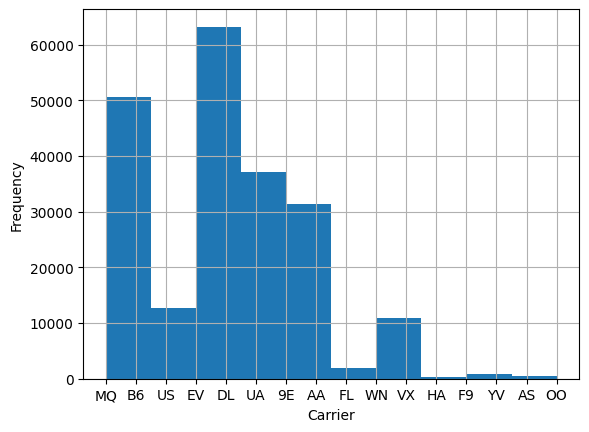

In [562]:
flights_train_copy['carrier'].hist()

plt.ylabel('Frequency')
plt.xlabel('Carrier')
plt.show()
# There's no "obvious" destination that we would want to impute missing values with
# Potentially come up with an "unknown" category for missing values here

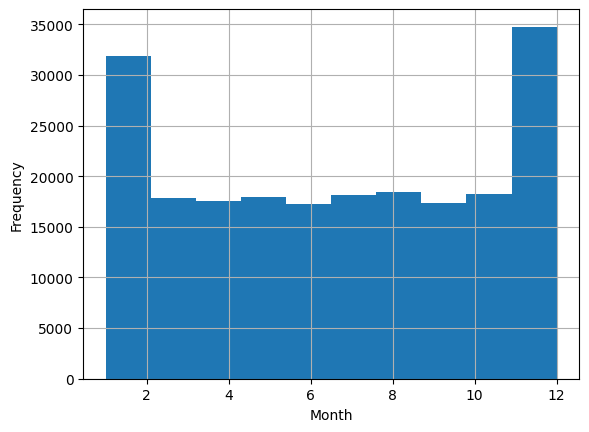

In [563]:
flights_train_copy['month'].hist()

plt.ylabel('Frequency')
plt.xlabel('Month')
plt.show()
# The largest number of flights are recorded over christmas
# But it doesn't make much sense to just assume a flight happens at this time
# Would either drop rows with missing month or potentially come up with an "unknown" category here

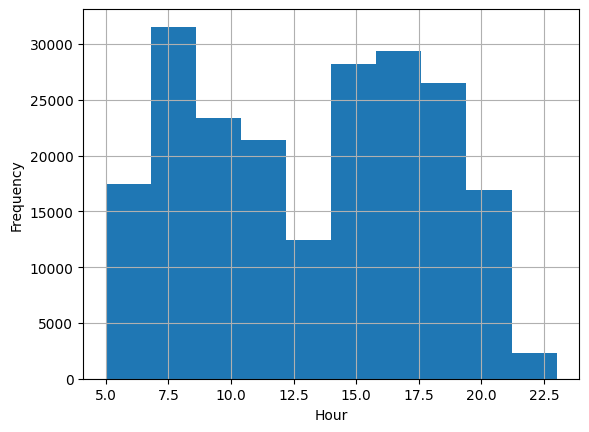

In [564]:
flights_train_copy['hour'].hist()

plt.ylabel('Frequency')
plt.xlabel('Hour')
plt.show()
# There are two peaks in the distribution of flight times
# Could impute missing values with one of these peaks or delete rows

Looking for any order in the data.

<Axes: ylabel='temp'>

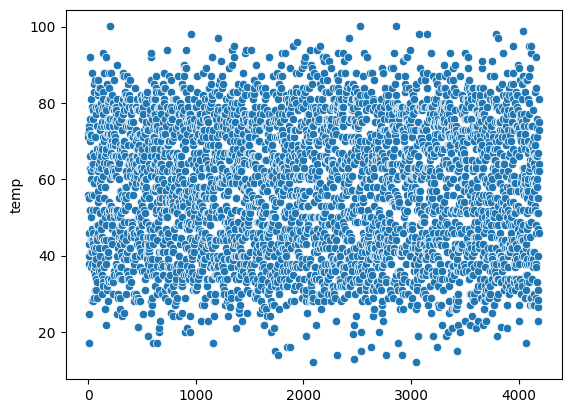

In [565]:
# Visualise a subset of the data since it's so large
# After trying out 100k, 10k and 1k, a subset of size 5k
# Gives a good balance of visualising the data clearly
# Take every 50th value
subset = flights_train_copy.iloc[::50]

sns.scatterplot(x=list(range(len(subset))), y=subset['temp'])

# There is no obvious pattern in the ordering of the temperature feature

<Axes: ylabel='dewp'>

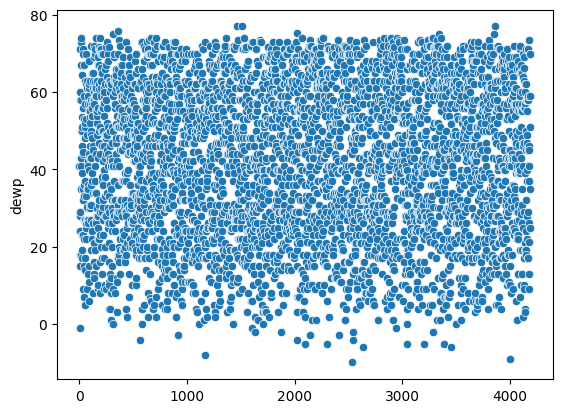

In [566]:
sns.scatterplot(x=list(range(len(subset))), y=subset['dewp'])

# There is no obvious pattern in the ordering of the dew point feature

<Axes: ylabel='humid'>

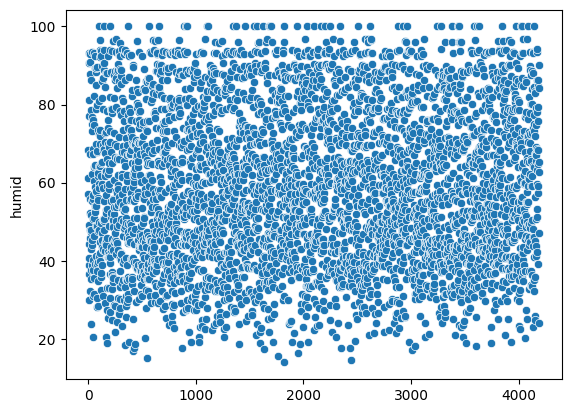

In [567]:
sns.scatterplot(x=list(range(len(subset))), y=subset['humid'])

# There is no obvious pattern in the ordering of the humidity feature

<Axes: ylabel='wind_speed'>

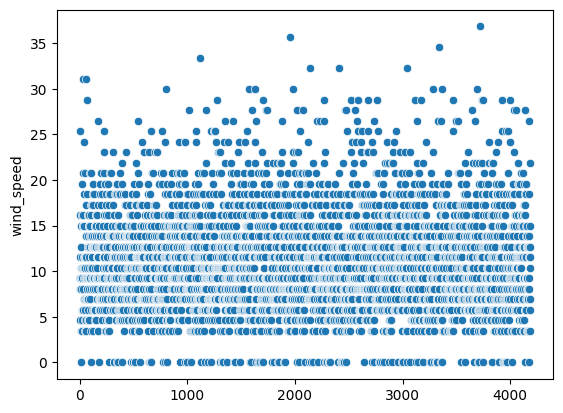

In [568]:
sns.scatterplot(x=list(range(len(subset))), y=subset['wind_speed'])

# There is no obvious pattern in the ordering of the wind_speed feature

<Axes: ylabel='precip'>

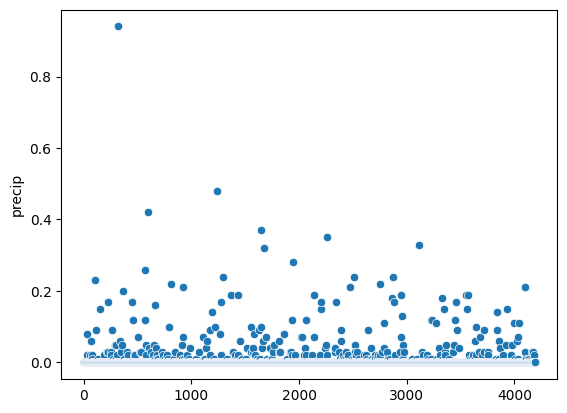

In [569]:
sns.scatterplot(x=list(range(len(subset))), y=subset['precip'])

# There is no obvious pattern in the ordering of the precipitation feature

<Axes: ylabel='visib'>

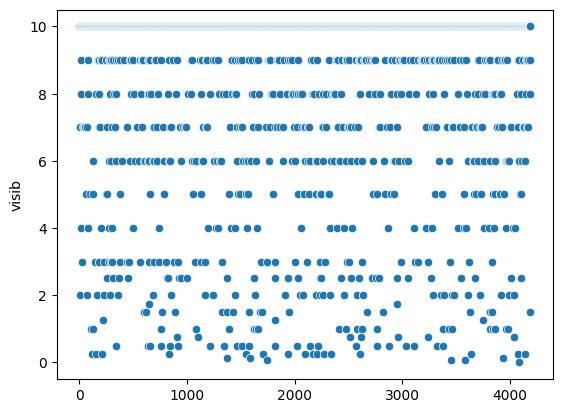

In [570]:
# Visualise a subset of the data since it's so large
sns.scatterplot(x=list(range(len(subset))), y=subset['visib'])

# There is no obvious pattern in the ordering of the visibility feature
# We could consider changing this into a categorical feature with bins for different levels of visibility
# Eg 0-2, 2-5, 5-10 and an "unknown" category for missing values

<Axes: ylabel='distance'>

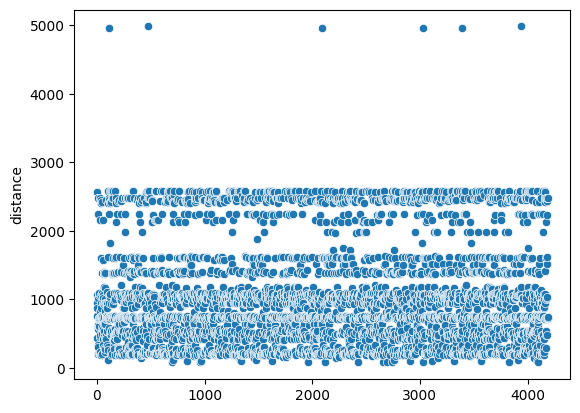

In [571]:
# Visualise a subset of the data since it's so large
sns.scatterplot(x=list(range(len(subset))), y=subset['distance'])

# There is no obvious pattern in the ordering of the distance feature

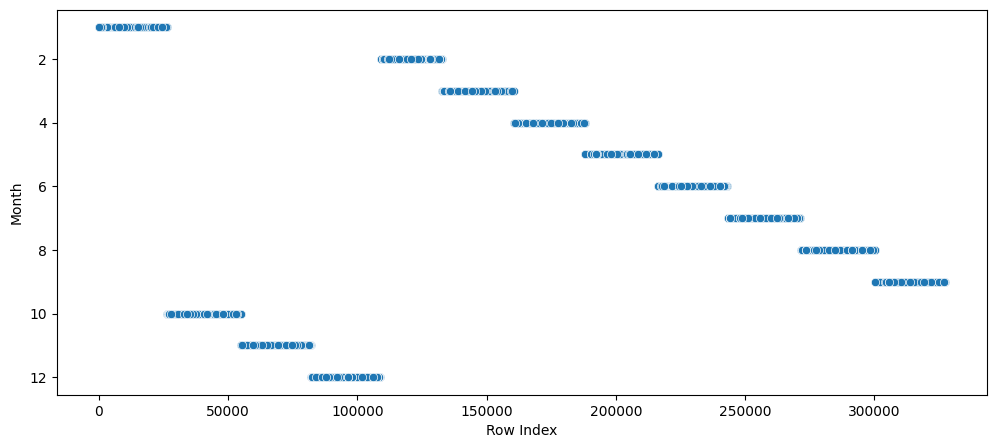

In [572]:
# Observing the raw data it looks chronologically ordered in some way
# Let's visualise the pattern
plt.figure(figsize=(12, 5))
sns.scatterplot(x=subset.index, y=subset['month'])
plt.ylabel("Month")
plt.xlabel("Row Index")
plt.show()

# Months have been ordered: 1, 10, 11, 12, 2, 3, 4, 5, 6, 7, 8, 9
# Make sure to shuffle the data before modelling to avoid any issues with this ordering

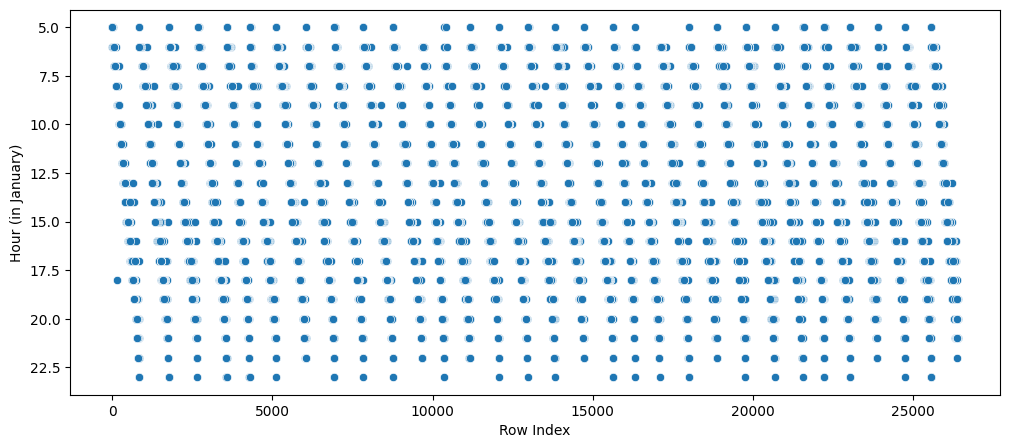

In [573]:
# Let's visualise the distribution of hour within the month january (1) to see if there's a pattern
month_subset = flights_train_copy[flights_train_copy['month'] == 1]

plt.figure(figsize=(12, 5))
sns.scatterplot(x=month_subset.index, y=month_subset['hour'])
plt.ylabel("Hour (in January)")
plt.xlabel("Row Index")
plt.show()

# It looks like hour increases from 5 to 23 for a day and then resets for any month (change 1 to 2, 3 to see same pattern)
# Another reason why we must shuffle the data when splitting

Look for relationships with the response feature (is_delayed) to see what might be a key predictor in the model.

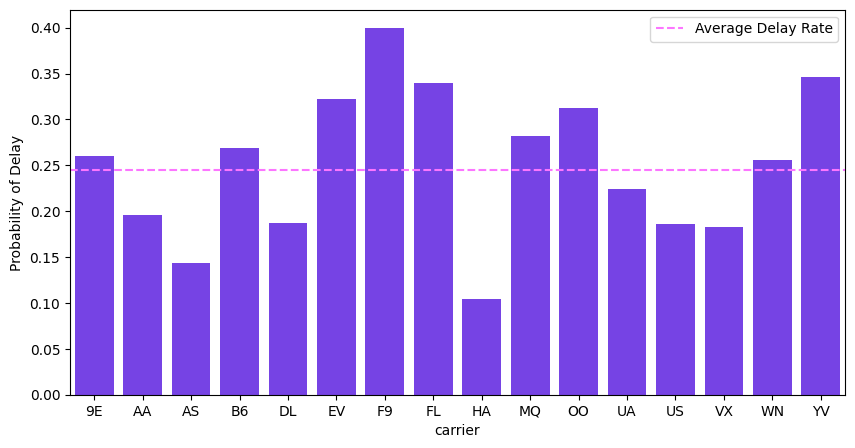

In [574]:
# Check if particular airline carrier have a relationship with delays by calculating the mean delay probability for each carrier
carrier_rel = flights_train_copy.groupby('carrier')['is_delayed'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=carrier_rel.index, y=carrier_rel.values, color='#6c28ff')
plt.axhline(flights_train_copy['is_delayed'].mean(), color='#fc76ff', linestyle='--', label='Average Delay Rate')
plt.ylabel('Probability of Delay')
plt.legend()
plt.show()

# It looks like some airlines (F9, FL, YV, and EV) clearly have higher delay probabilities than others
# This may be a valuable predictor

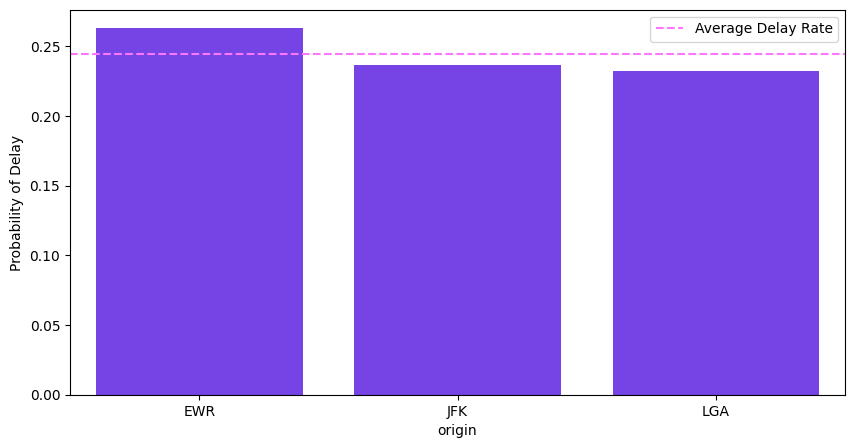

In [575]:
# Check if particular origin airports have a relationship with delays by calculating the mean delay probability for each origin
origin_rel = flights_train_copy.groupby('origin')['is_delayed'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=origin_rel.index, y=origin_rel.values, color='#6c28ff')
plt.axhline(flights_train_copy['is_delayed'].mean(), color='#fc76ff', linestyle='--', label='Average Delay Rate')
plt.ylabel('Probability of Delay')
plt.legend()
plt.show()

# It looks like each airport has a different delay probability
# So this may also be a valuable predictor

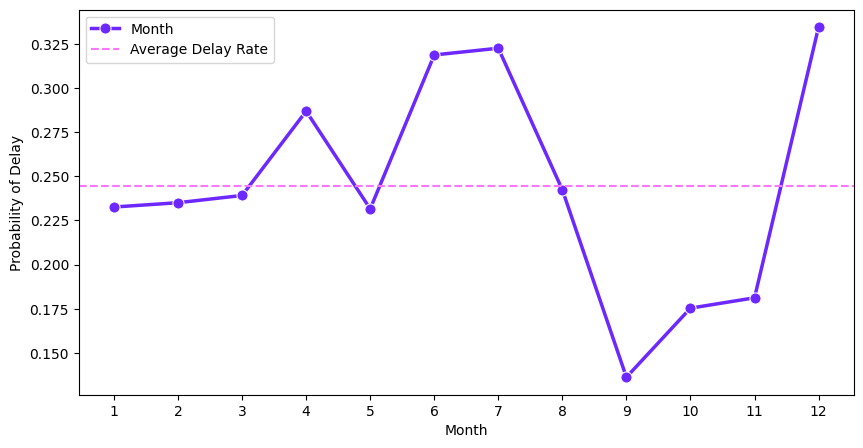

In [576]:
month_rel = flights_train_copy.groupby('month')['is_delayed'].mean().sort_values(ascending=False)

# A line plot is more suitable for temporal data since it shows the trend more clearly than a bar plot
plt.figure(figsize=(10,5))
sns.lineplot(
    x=month_rel.index,
    y=month_rel.values,
    marker='o', 
    markersize=8,
    color='#6c28ff',
    linewidth=2.5,
    label='Month'
)

plt.xticks(range(1, 13))
plt.axhline(flights_train_copy['is_delayed'].mean(), color='#fc76ff', linestyle='--', label='Average Delay Rate')
plt.xlabel('Month')
plt.ylabel('Probability of Delay')
plt.legend()
plt.show()

# It looks like there is a clear relationship between month and delay probability
# Summer months (June and July) and Christmas holidays (December) appear to have higher delay probabilities than other months
# This looks like it will be a valuable predictor

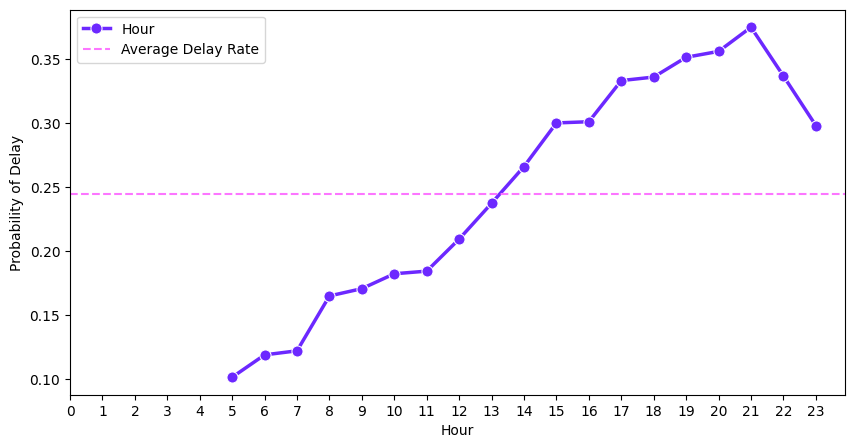

In [577]:
hour_rel = flights_train_copy.groupby('hour')['is_delayed'].mean().sort_values(ascending=False)

# A line plot is more suitable for this data as well
plt.figure(figsize=(10,5))
sns.lineplot(
    x=hour_rel.index,
    y=hour_rel.values,
    marker='o', 
    markersize=8,
    color='#6c28ff',
    linewidth=2.5,
    label='Hour'
)

plt.xticks(range(0, 24))
plt.axhline(flights_train_copy['is_delayed'].mean(), color='#fc76ff', linestyle='--', label='Average Delay Rate')
plt.xlabel('Hour')
plt.ylabel('Probability of Delay')
plt.legend()
plt.show()

# It looks like there is a clear relationship between hour and delay probability as well
# Flights become more likely to be delayed as the day goes on
# This will also likely be a valuable predictor

For the continuous features we will mainly use box plots to observe any potential relationships with the response is_delayed.

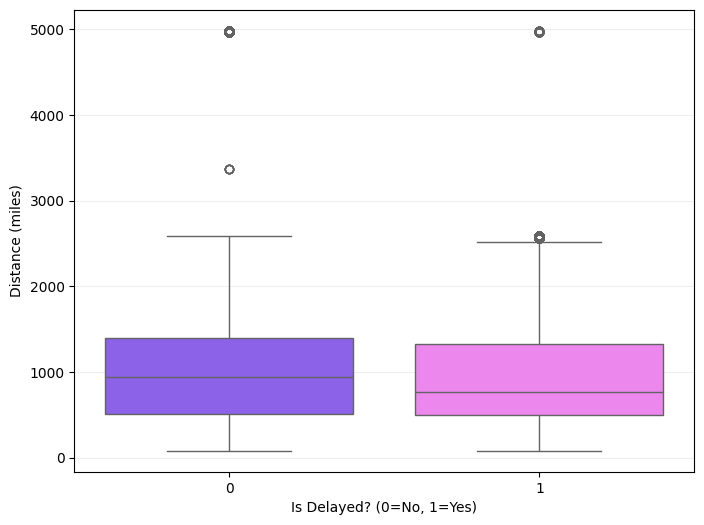

In [578]:
plt.figure(figsize=(8, 6))

colour_palette = {0: "#844bff", 1: "#fc76ff"}

sns.boxplot(
    data=flights_train_copy,
    x='is_delayed',
    y='distance',
    hue='is_delayed', 
    palette=colour_palette,
    legend=False
)

plt.xlabel('Is Delayed? (0=No, 1=Yes)')
plt.ylabel('Distance (miles)')
plt.grid(axis='y', alpha=0.2)
plt.show()

# It seems like there isn't an obvious relationship between flight distance and delay probability

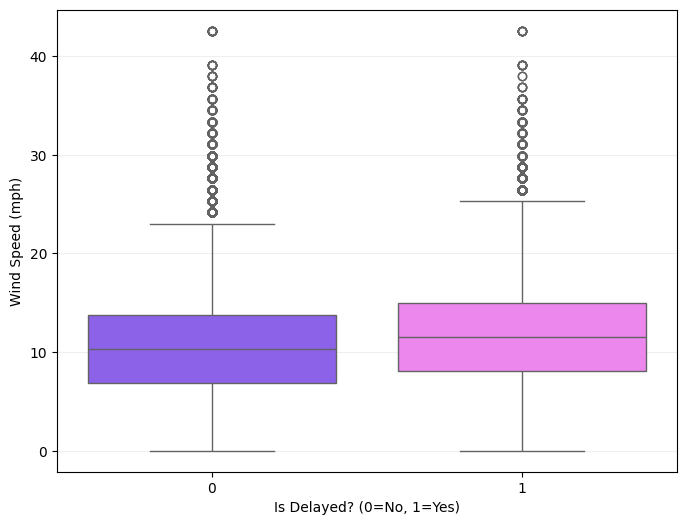

In [579]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=flights_train_copy,
    x='is_delayed',
    y='wind_speed',
    hue='is_delayed', 
    palette=colour_palette,
    legend=False
)

plt.xlabel('Is Delayed? (0=No, 1=Yes)')
plt.ylabel('Wind Speed (mph)')
plt.grid(axis='y', alpha=0.2)
plt.show()

# Higher wind speeds seem to be associated with higher delay probabilities, so this may be a viable predictor

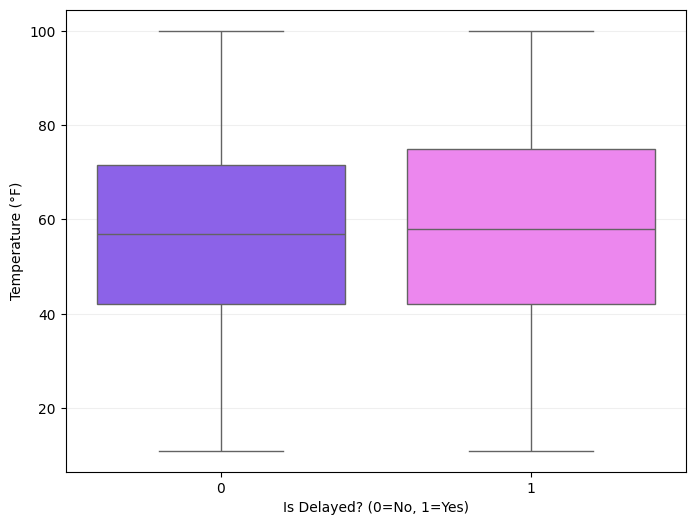

In [580]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=flights_train_copy,
    x='is_delayed',
    y='temp',
    hue='is_delayed',
    palette=colour_palette,
    legend=False
)

plt.xlabel('Is Delayed? (0=No, 1=Yes)')
plt.ylabel('Temperature (°F)')
plt.grid(axis='y', alpha=0.2)
plt.show()

# There may be some relationship between temperature and delay probability, but this is less clear

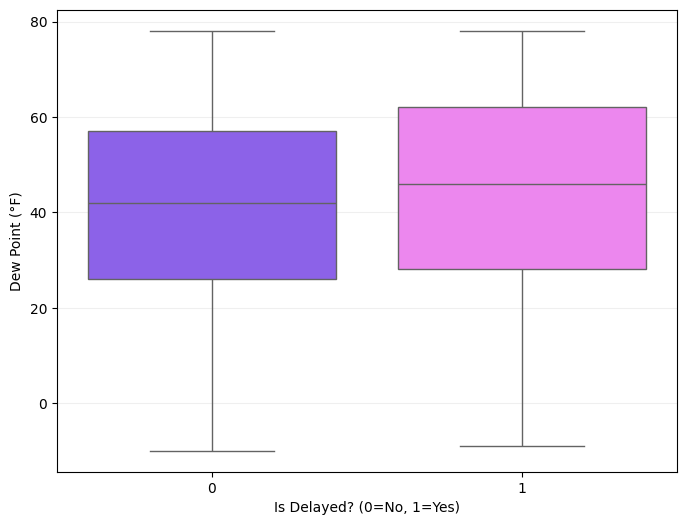

In [581]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=flights_train_copy,
    x='is_delayed',
    y='dewp',
    hue='is_delayed', 
    palette=colour_palette,
    legend=False
)

plt.xlabel('Is Delayed? (0=No, 1=Yes)')
plt.ylabel('Dew Point (°F)')
plt.grid(axis='y', alpha=0.2)
plt.show()

# Higher dew points seem to have a relationship with higher delay probabilities, so this may be a viable predictor

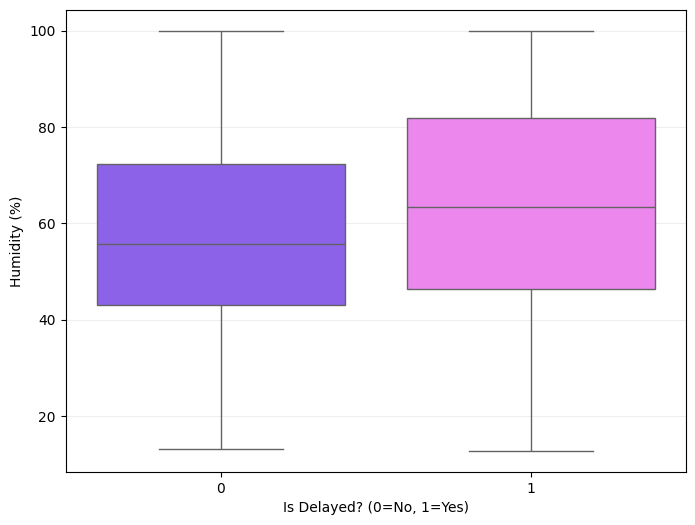

In [582]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=flights_train_copy,
    x='is_delayed',
    y='humid',
    hue='is_delayed', 
    palette=colour_palette,
    legend=False
)

plt.xlabel('Is Delayed? (0=No, 1=Yes)')
plt.ylabel('Humidity (%)')
plt.grid(axis='y', alpha=0.2)
plt.show()

# It looks like there's a relationship between higher humidity and higher delay probabilities, so this may also be a viable predictor

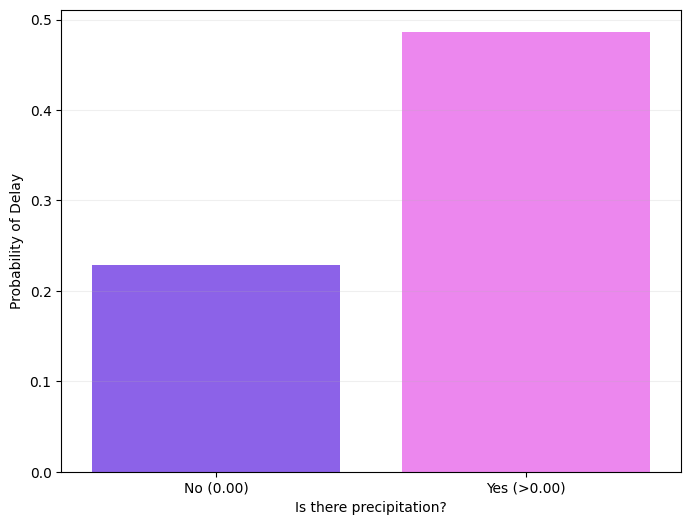

In [583]:
# Precipitation needs a different approach because of the extreme distribution shape
# We will instead create a binary label for whether there is any precipitation (>0) or not (0) and see if this has a relationship with delay probability
flights_train_copy['has_precip'] = flights_train_copy['precip'] > 0

# Calculate the average delay rate precipitation vs no precipitation
delay_stats = flights_train_copy.groupby('has_precip')['is_delayed'].mean()

plt.figure(figsize=(8, 6))
sns.barplot(
    x=delay_stats.index,
    y=delay_stats.values,
    hue=delay_stats.index,
    palette=colour_palette,
    legend=False
)

plt.xlabel('Is there precipitation?')
plt.ylabel('Probability of Delay')
plt.xticks(ticks=[0, 1], labels=['No (0.00)', 'Yes (>0.00)'])
plt.grid(axis='y', alpha=0.2)
plt.show()

# It looks like there's a clear relationship between precipitation and delay probability
# So it would be worthwhile to consider changing this numerical feature into a categorical one (either binary or with different bins)
# To serve as a key predictor in the model

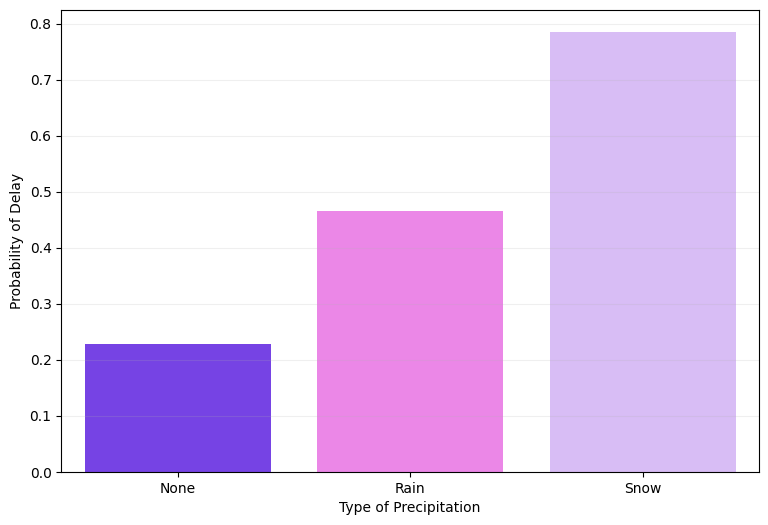

In [584]:
# Idea: what if we can split precipitation further into what type of precipitation it is (eg rain vs snow) by using the temperature feature as well?
conditions = [
    (flights_train_copy['precip'] == 0),
    (flights_train_copy['precip'] > 0) & (flights_train_copy['temp'] > 32),
    (flights_train_copy['precip'] > 0) & (flights_train_copy['temp'] <= 32)
]
choices = ['None', 'Rain', 'Snow']

flights_train_copy['weather_type'] = np.select(conditions, choices, default='None')

# Calculate average delay rate for each category
# We sort them to ensure the bar chart follows a logical order
delay_stats = flights_train_copy.groupby('weather_type')['is_delayed'].mean().reindex(['None', 'Rain', 'Snow'])

plt.figure(figsize=(9, 6))
sns.barplot(
    x=delay_stats.index, 
    y=delay_stats.values, 
    hue=delay_stats.index,
    palette=['#6c28ff', '#fc76f7', '#d8b4fe'], # Using your purple/pink theme
    legend=False
)

plt.xlabel('Type of Precipitation')
plt.ylabel('Probability of Delay')
plt.grid(axis='y', alpha=0.2)
plt.show()

# It looks like there's a stronger relationship when we break up precipitation like this instead

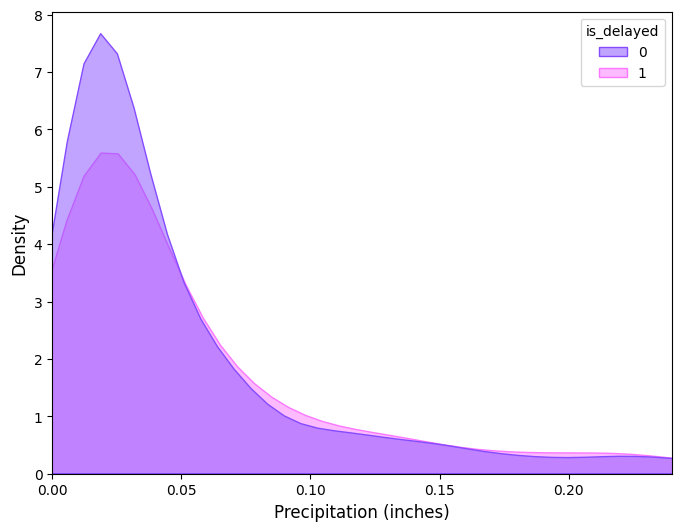

In [585]:
# To see whether it would be worthwhile to split into binary bins or more, we will visualise the distribution of precipitation
# for delayed vs non-delayed flights
plt.figure(figsize=(8, 6))

# Filter only for flights that actually had rain
rainy_flights = flights_train_copy[flights_train_copy['precip'] > 0]

sns.kdeplot(
    data=rainy_flights,
    x='precip',
    hue='is_delayed',
    fill=True, 
    palette=colour_palette,
    alpha=0.5
)

plt.xlabel('Precipitation (inches)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, rainy_flights['precip'].quantile(0.95)) # Zoom in on the most common rain amounts (up to 95th percentile)
plt.show()

# It looks like there isn't a clear relationship between the amount of precipitation and delay probability
# So it may be sufficient to just split into binary bins for whether there is precipitation or not

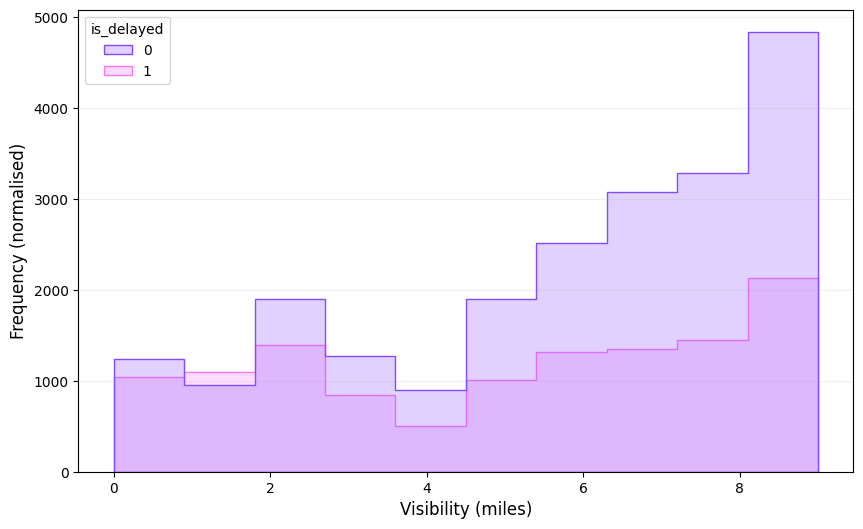

In [586]:
# Check whether there's a relationship between visibility and delay probability
plt.figure(figsize=(10, 6))

# Excluding 10 since this makes it hard to view delay/non-delay split for lower visibility levels
low_visibility_flights = flights_train_copy[flights_train_copy['visib'] < 10]

sns.histplot(
    data=low_visibility_flights,
    x='visib',
    hue='is_delayed', 
    element="step",
    palette=colour_palette, 
    bins=10,
    common_norm=False
)

plt.xlabel('Visibility (miles)', fontsize=12)
plt.ylabel('Frequency (normalised)', fontsize=12)
plt.grid(axis='y', alpha=0.2)
plt.show()

# It looks like there is a clear relationship between visibility and delay probability
# Lower visibility levels being associated with higher delay probabilities
# This may also benefit from being categorised into multiple bins instead of a numerical feature

### Check correlations

See if there are any highly correlated features which may be too similar. We would want to avoid having two very similar attributes in the model because it doesn't provide much additional information and risk overfitting.

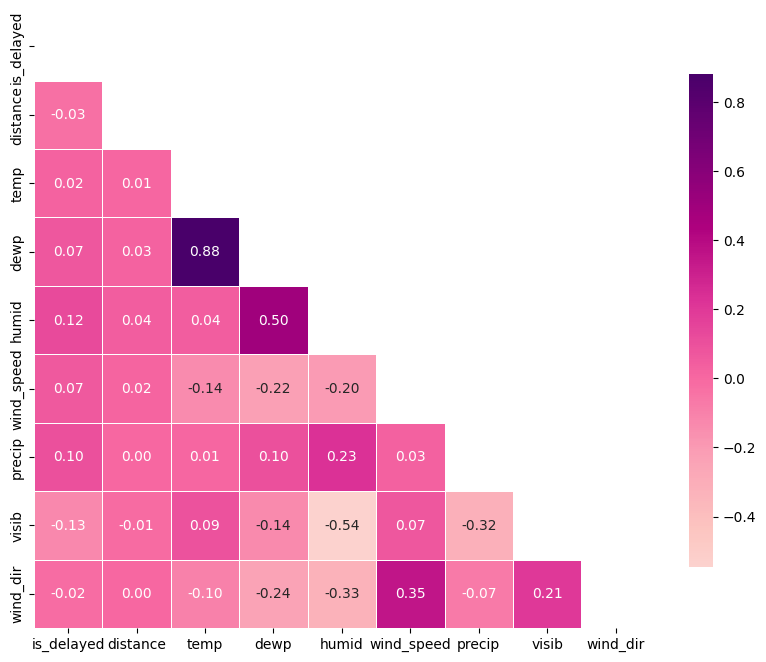

In [587]:
# Include all continuous features and the response variable (is_delayed) for the correlation matrix
numeric_vars = ['is_delayed', 'distance', 'temp', 'dewp', 'humid', 'wind_speed', 'precip', 'visib', 'wind_dir']
corr_matrix = flights_train_copy[numeric_vars].corr()

# Can just take the lower triangle of the correlation matrix to avoid redundancy since it's symmetric
# https://numpy.org/doc/stable/reference/generated/numpy.triu.html
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

# We can use a heatmap to easily visualise the correlations between features
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='RdPu',
    center=0,
    square=True,
    linewidths=.5, 
    cbar_kws={"shrink": .8}
)

plt.show()

# dewp and temp have a high correlation, so we will drop temp (since it has a lower correlation with is_delayed) to avoid multicollinearity
# visib and humid also have a high correlation, but we will keep both of these since they have a higher correlation with is_delayed
# We could also keep wind_speed and precip, bearing in mind that if they are categories they may have a strong relationship with is_delayed

### 4. Revised Data Cleaning
* Remove rows with lots of missing data
* Remove columns with lots of missing data
* Fill in values based off insights from data exploration

In [588]:
# Reminder of feature which have null values
flights_train_copy.info()

<class 'pandas.DataFrame'>
Index: 209500 entries, 59674 to 186079
Data columns (total 30 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   year            209500 non-null  int64   
 1   month           209500 non-null  category
 2   day             209500 non-null  int64   
 3   dep_time        209500 non-null  float64 
 4   sched_dep_time  209500 non-null  int64   
 5   dep_delay       209500 non-null  float64 
 6   arr_time        209500 non-null  float64 
 7   sched_arr_time  209500 non-null  int64   
 8   arr_delay       209500 non-null  float64 
 9   carrier         209500 non-null  category
 10  flight          209500 non-null  int64   
 11  tailnum         209500 non-null  str     
 12  origin          209500 non-null  category
 13  dest            209500 non-null  category
 14  air_time        209500 non-null  float64 
 15  distance        209500 non-null  int64   
 16  hour            209500 non-null  category
 17  min

In [589]:
# temp, dewp, humid, wind_dir, wind_speed, precip, and visib have some null values
# wind_dir we will drop now since it has a low correlation with the response and no clear distribution
# we will impute the others

# Drop wind_dir from the training set
flights_train_copy = flights_train_copy.drop(columns=['wind_dir'])

# temp, dewp, humid, wind_speed, and distance will be imputed with the median
median_features = ['temp', 'dewp', 'humid', 'wind_speed', 'distance']

# precip and visib will be imputed with the mode
mode_features = ['precip', 'visib']

median_imputer = SimpleImputer(strategy='median')
mode_imputer = SimpleImputer(strategy='most_frequent')

flights_train_copy[median_features] = median_imputer.fit_transform(flights_train_copy[median_features])
flights_train_copy[mode_features] = mode_imputer.fit_transform(flights_train_copy[mode_features])

# Sanity check there are no more null values
flights_train_copy.isna().sum(axis=0).to_frame(name='# of Missing Values')

,# of Missing Values
year,0
month,0
day,0
dep_time,0
sched_dep_time,0
dep_delay,0
arr_time,0
sched_arr_time,0
arr_delay,0
carrier,0


### 5. (Exploring) Feature Engineering

Would it be useful to change any numerical attributes into categorical ones?

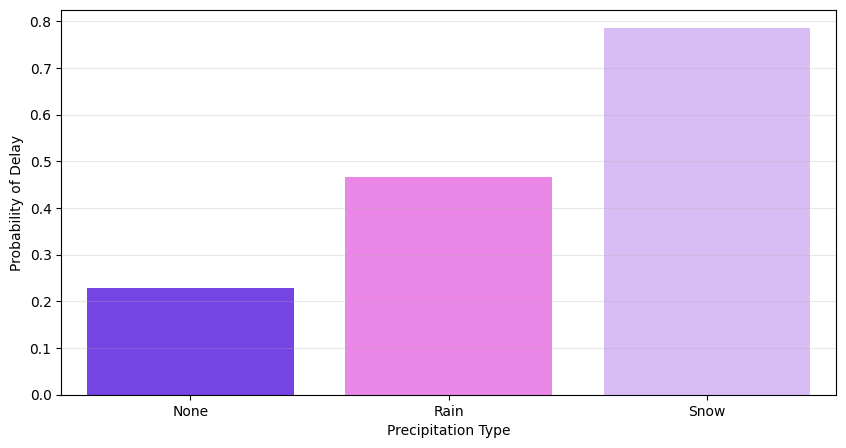

In [590]:
# Make a new feature precip_cat (categorical) feature with "None", "Rain" and "Snow" using temperature and precip
conditions = [
    (flights_train_copy['precip'] == 0),
    (flights_train_copy['precip'] > 0) & (flights_train_copy['temp'] > 32),
    (flights_train_copy['precip'] > 0) & (flights_train_copy['temp'] <= 32)
]
choices = ['None', 'Rain', 'Snow']

flights_train_copy['precip_cat'] = np.select(conditions, choices, default='None')
flights_train_copy['precip_cat'] = flights_train_copy['precip_cat'].astype('category')

# Plot the relationship between has_precip and is_delayed to confirm the relationship after categorisation
plt.figure(figsize=(10, 5))
vis_rel = flights_train_copy.groupby('precip_cat')['is_delayed'].mean().reindex(['None', 'Rain', 'Snow'])

# Using your purple theme with slight variations to distinguish the three types
sns.barplot(
    x=vis_rel.index, 
    y=vis_rel.values, 
    hue=vis_rel.index,   # Now the palette knows what to color
    palette=['#6c28ff', '#fc76f7', '#d8b4fe'],
    legend=False         # Removes the redundant legend
)

plt.ylabel('Probability of Delay')
plt.xlabel('Precipitation Type')
plt.grid(axis='y', alpha=0.3)
plt.show()

# This looks like it would be a valuable transformation to make

Text(0.5, 0, 'Precipitation Type')

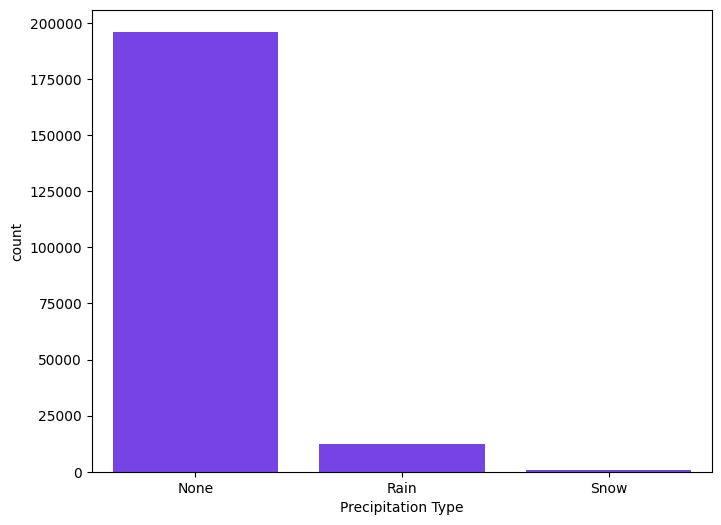

In [591]:
# Look at the distribution of precipitation type
plt.figure(figsize=(8, 6))
sns.countplot(data=flights_train_copy, x='precip_cat', color='#6c28ff')
plt.xlabel('Precipitation Type')

# We would impute with 'None' here

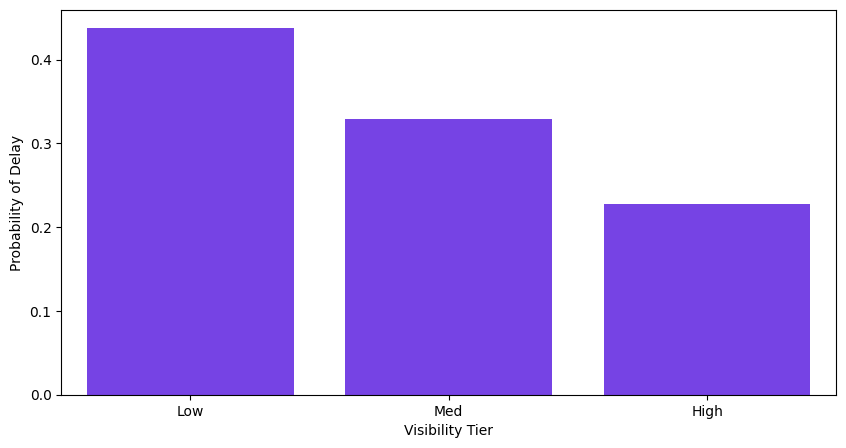

In [592]:
# Change visib into a categorical feature with 3 bins: low, medium, and high visibility
bins = [-1, 4, 7, 10]
labels = ['Low', 'Med', 'High']
flights_train_copy['visib_cat'] = pd.cut(flights_train_copy['visib'], bins=bins, labels=labels)

# Plot the relationship between visib_cat and is_delayed to confirm the relationship after categorisation
plt.figure(figsize=(10, 5))

vis_rel = flights_train_copy.groupby('visib_cat')['is_delayed'].mean()

sns.barplot(x=vis_rel.index, y=vis_rel.values, color='#6c28ff')

plt.ylabel('Probability of Delay')
plt.xlabel('Visibility Tier')
plt.show()

# This also looks like it would be a valuable transformation to make

Text(0.5, 0, 'Visibility Tier')

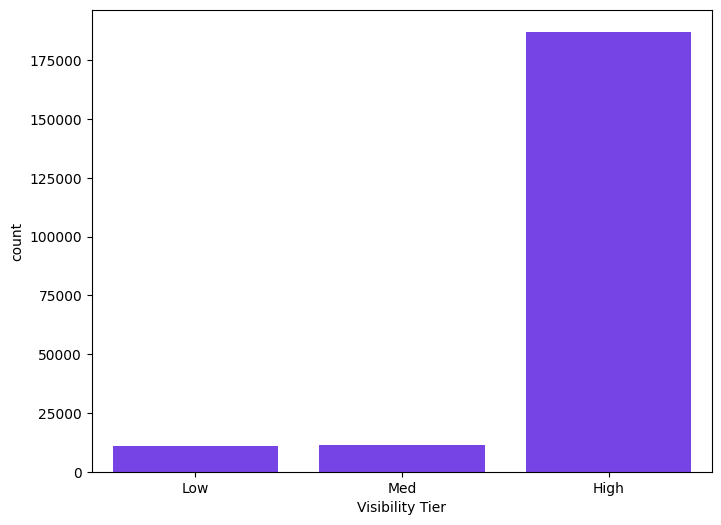

In [593]:
# Look at distribution of visibility tier
plt.figure(figsize=(8, 6))
sns.countplot(data=flights_train_copy, x='visib_cat', color='#6c28ff')
plt.xlabel('Visibility Tier')

# We would impute with 'High' visibility here

## Preparing a Pipeline
Based off of what we now know from the data we need to build a pipeline which:
* Selects which features to keep
* Cleans and imputes the data, considering NA values
* Performs any suitable feature engineering
* Prepares the data for interpretation by a ML model (one_hot and scaling)

`precip` and `visib` will be changed into categorical variables based off of the data exploration. `precip` will be changed into a binary label `has_precip` and `visib` will be changed into low/med/high bins since there's a more varied distribution.

The following features will be used based off of their perceived relationship and/or correlation with the response, `is_delayed`:
* month
* carrier
* origin
* hour
* dewp
* humid
* has_precip (feature engineered from precip)
* visib_cat (feature engineered from visib)

In [684]:
def transformer_categorical(X):
    # Change precip into a categorical feature with "None", "Rain", and "Snow" using temperature and precip
    # DEPRECATED
    # X['has_precip'] = (X['precip'] > 0).map({True: 'Yes', False: 'No'})
    # X['has_precip'] = X['has_precip'].astype('category')
    # END OF DEPRECATED
    conditions = [
        (X['precip'] == 0),
        (X['precip'] > 0) & (X['temp'] > 32),
        (X['precip'] > 0) & (X['temp'] <= 32)
    ]
    choices = ['None', 'Rain', 'Snow']
    
    X['weather_conditions'] = np.select(conditions, choices, default='None')
    X['weather_conditions'] = X['weather_conditions'].astype('category')

    # Change visib into a categorical feature with 3 bins: low, medium, and high visibility
    bins = [-1, 4, 7, 10]
    labels = ['Low', 'Med', 'High']
    X['visib_cat'] = pd.cut(X['visib'], bins=bins, labels=labels)   

    # Drop the original precip, visib, and temp columns since they've been transformed
    X = X.drop(columns=['precip', 'visib']) # 'temp' WAS IN HERE BUT TOOK OUT FOR NOW

    return X

def clean_and_prep(X, features_selected, median_imputer, mode_imputer):
    X = X.copy() # Safety measure

    # Impute missing values (note transform only and not fit since we don't want to fit the test set)
    X[median_features] = median_imputer.transform(X[median_features])
    X[mode_features] = mode_imputer.transform(X[mode_features])

    # Transform numerical attributes (precip and visib) into categorical (has_precip and visib_cat)
    X = transformer_categorical(X)

    # Filter features 
    X = X[features_selected]

    return X

In [685]:
# temp, dewp, humid, wind_speed, and distance will be imputed with the median
median_features = ['temp', 'dewp', 'humid', 'wind_speed', 'distance']
# precip and visib will be imputed with the mode
mode_features = ['precip', 'visib']

# Define and fit the imputers on the training data only
# https://www.youtube.com/watch?v=6as06vtXNL8
median_imputer = SimpleImputer(strategy='median')
mode_imputer = SimpleImputer(strategy='most_frequent')

# Fit the imputers on the training data (and NOT the validation or test data to avoid data leakage)
median_imputer.fit(flights_train_raw[median_features])
mode_imputer.fit(flights_train_raw[mode_features])

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [717]:
# Features selected based on the exploratory data analysis
features_selected = ["month", "carrier", "origin", "hour", "wind_speed", "visib_cat", "dewp", "weather_conditions"] # Distance, humid, temp REMOVED

# Extract the response variable from the training, validation, and test sets before running the pipeline
train_labels = flights_train_raw['is_delayed']
validation_labels = flights_validation_raw['is_delayed']
test_labels = flights_test_raw['is_delayed']

# Clean and prepare the raw training data (NOT the copy used for exploration)
cleaned_training_data = clean_and_prep(flights_train_raw, features_selected, median_imputer, mode_imputer)
cleaned_validation_data = clean_and_prep(flights_validation_raw, features_selected, median_imputer, mode_imputer)
cleaned_test_data = clean_and_prep(flights_test_raw, features_selected, median_imputer, mode_imputer)

# Define the numerical and categorical attributes
numerical_attributes = ["dewp", "wind_speed"] # Distance, humid removed
categorical_attributes = ["month", "carrier", "origin", "hour", "visib_cat", "weather_conditions"]

# Define the pipeline
full_pipeline = ColumnTransformer([
    ("numerical", StandardScaler(), numerical_attributes),
    ("categorical", OneHotEncoder(sparse_output=False), categorical_attributes),
])
full_pipeline.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

In [718]:
# Run the pipeline
prepared_training_data = full_pipeline.fit_transform(cleaned_training_data)
prepared_validation_data = full_pipeline.transform(cleaned_validation_data)
prepared_test_data = full_pipeline.transform(cleaned_test_data)

## Building Classification Models

We will build and train 4 different machine learning models on the training set and then pick the best one using the validation set. The 4 classification models we will train are:
* Logistic Regression
* Stochastic Gradient Descent
* Random Forest
* XGBoost

In [719]:
# Logistic Regression
# class_weight='balanced' to account for imbalanced dataset
logistic_regression_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# See if this improves on the simple logi stic regression model
sgd_model = SGDClassifier(
    loss='log_loss', 
    class_weight='balanced', 
    random_state=42, 
    max_iter=1000, 
    tol=1e-3
)

# Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10, # Limits depth so it can't just memorise the training data
    min_samples_leaf=50, # Requires 50 flights to make a rule
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 # Use all cores to speed up training since this is a computationally expensive model
)

# HistGradientBoosting
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html#sklearn.ensemble.HistGradientBoostingClassifier
hist_gradient_boosting_model = HistGradientBoostingClassifier(
    loss='log_loss',
    learning_rate=0.1,
    max_iter=100,
    max_leaf_nodes=31,
    max_depth=None,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

In [720]:
# Fit the models on the training set

logistic_regression_model.fit(prepared_training_data, train_labels)

sgd_model.fit(prepared_training_data, train_labels)

random_forest_model.fit(prepared_training_data, train_labels)

hist_gradient_boosting_model.fit(prepared_training_data, train_labels)

print("All models have been trained successfully!")

All models have been trained successfully!


Now the models have been trained, we should generate the predictions and probability scores to see how well they generalise the validation set.

In [721]:
# Look at how they perform on the training data
training_model_results = {}

for name, model in {"LR": logistic_regression_model,
                    "SGD": sgd_model,
                    "RF": random_forest_model, 
                    "HGB": hist_gradient_boosting_model}.items():
    
    preds = model.predict(prepared_training_data)
    probs = model.predict_proba(prepared_training_data)[:, 1]
    
    training_model_results[name] = {
        'preds': preds,
        'probs': probs,
        'recall': recall_score(train_labels, preds),
        'f1': f1_score(train_labels, preds)
    }

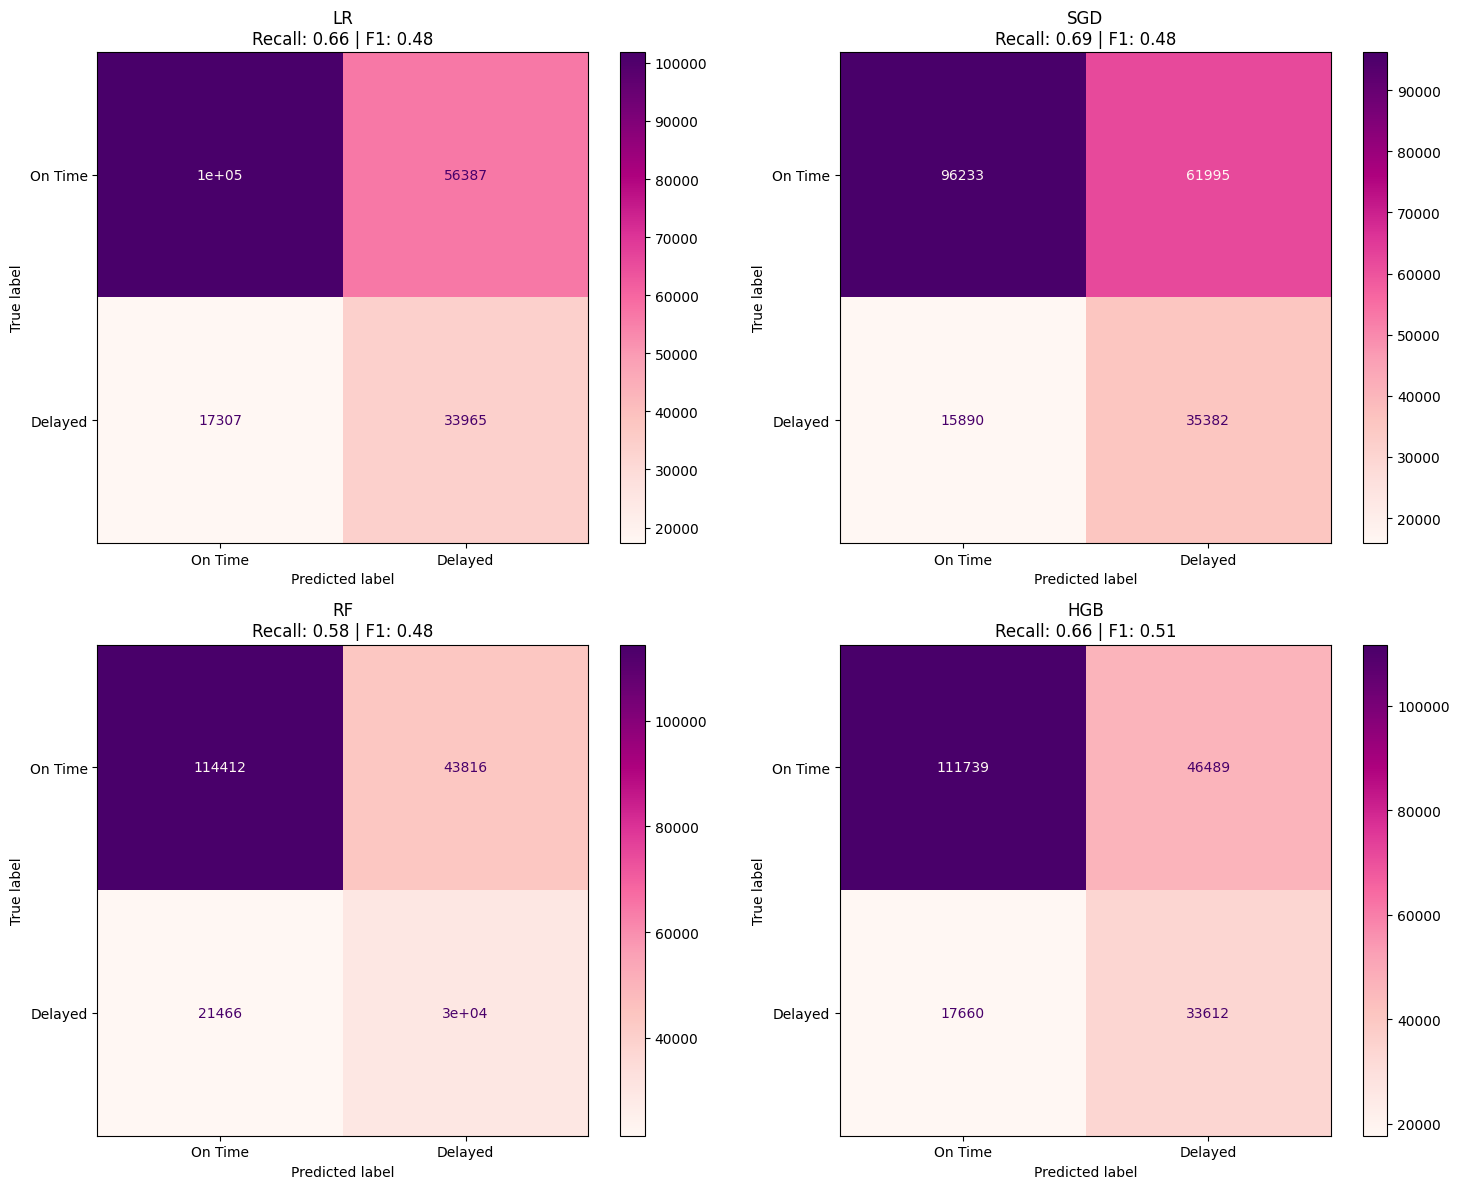

In [722]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, data) in enumerate(training_model_results.items()):
    cm = confusion_matrix(train_labels, data['preds'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time', 'Delayed'])
    disp.plot(ax=axes[i], cmap='RdPu', colorbar=True)
    axes[i].set_title(f"{name}\nRecall: {data['recall']:.2f} | F1: {data['f1']:.2f}")

plt.tight_layout()
plt.show()

In [723]:
# Look at how they perform on the validation data and compare results
validation_model_results = {}

for name, model in {"LR": logistic_regression_model,
                    "SGD": sgd_model,
                    "RF": random_forest_model, 
                    "HGB": hist_gradient_boosting_model}.items():
    
    preds = model.predict(prepared_validation_data)
    probs = model.predict_proba(prepared_validation_data)[:, 1]
    
    validation_model_results[name] = {
        'preds': preds,
        'probs': probs,
        'recall': recall_score(validation_labels, preds),
        'f1': f1_score(validation_labels, preds)
    }

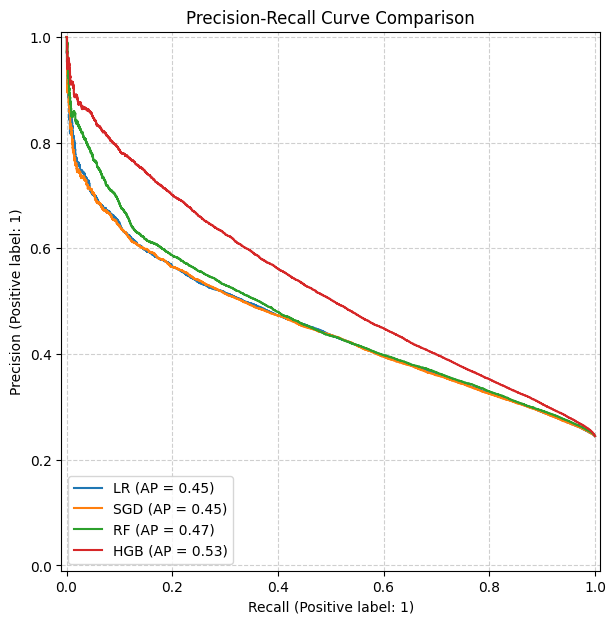

In [724]:
plt.figure(figsize=(10, 7))
ax = plt.gca()

for name, data in training_model_results.items():
    PrecisionRecallDisplay.from_predictions(
        train_labels, 
        data['probs'], 
        name=name, 
        ax=ax
    )

plt.title("Precision-Recall Curve Comparison")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

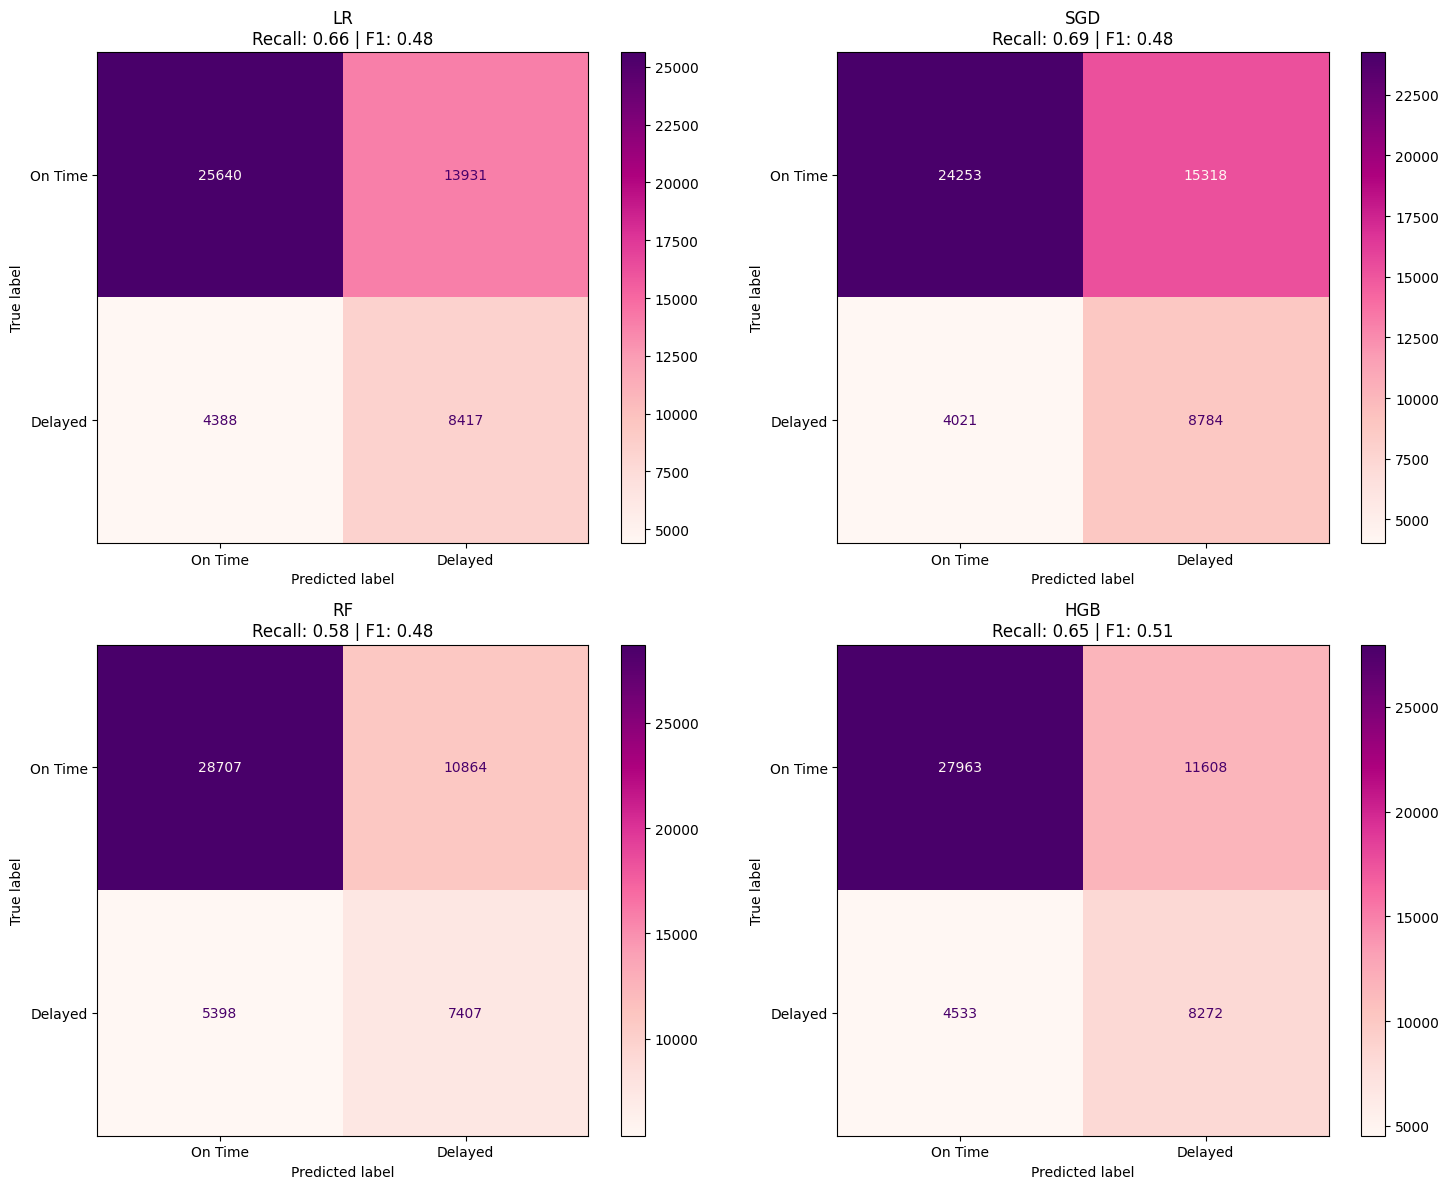

In [725]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, data) in enumerate(validation_model_results.items()):
    cm = confusion_matrix(validation_labels, data['preds'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time', 'Delayed'])
    disp.plot(ax=axes[i], cmap='RdPu', colorbar=True)
    axes[i].set_title(f"{name}\nRecall: {data['recall']:.2f} | F1: {data['f1']:.2f}")

plt.tight_layout()
plt.show()

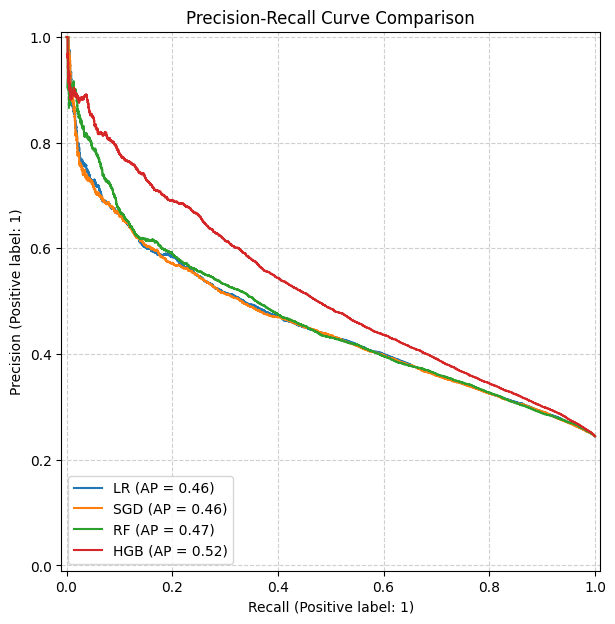

In [726]:
plt.figure(figsize=(10, 7))
ax = plt.gca()

for name, data in validation_model_results.items():
    PrecisionRecallDisplay.from_predictions(
        validation_labels, 
        data['probs'], 
        name=name, 
        ax=ax
    )

plt.title("Precision-Recall Curve Comparison")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Remember dataset is imbalanced (0.25 delayed vs 0.75 on time)

## Fine Tune the Best Model

Picking histogram-based gradient boosting classification tree.

In [727]:
# Define the parameter grid
param_dist = {
    'learning_rate': [0.01, 0.025, 0.05, 0.075, 0.1],
    'max_iter': [100, 200, 300],
    'max_leaf_nodes': [20, 30, 60],
    'max_depth': [3, 6, 9],
    'min_samples_leaf': [15, 50, 75, 100, 125]
}

# Run the randomised search
random_search = RandomizedSearchCV(
    estimator=hist_gradient_boosting_model,
    param_distributions=param_dist,
    n_iter=20, # number of random combinations to try
    scoring='recall', # prioritising recall over precision
    cv=3, # 3-fold cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1 # Use all available processors
)

# Fit the search to your prepared data
random_search.fit(prepared_training_data, train_labels)

# Extract the best model
# best_xgb_model = random_search.best_estimator_
print(f"Best parameters: {random_search.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'min_samples_leaf': 75, 'max_leaf_nodes': 60, 'max_iter': 200, 'max_depth': 6, 'learning_rate': 0.075}


In [729]:
# Initialise the final tuned model with the best parameters found
final_model = HistGradientBoostingClassifier(
    loss='log_loss',
    learning_rate=0.075,
    max_iter=200,
    max_leaf_nodes=60,
    max_depth=6,
    min_samples_leaf=75,
    class_weight='balanced',
    random_state=42
)

# Fit the model to your prepared training data
final_model.fit(prepared_training_data, train_labels)

print("Final tuned model is ready.")

Final tuned model is ready.


In [730]:
# Make predictions
final_preds = final_model.predict(prepared_validation_data)

# Check Recall
tuned_recall = recall_score(validation_labels, final_preds)
print(f"Tuned Model Recall: {tuned_recall:.4f}")

# Full report to see the Precision-Recall trade-off
print(classification_report(validation_labels, final_preds))

Tuned Model Recall: 0.6482
              precision    recall  f1-score   support

           0       0.86      0.71      0.78     39571
           1       0.42      0.65      0.51     12805

    accuracy                           0.69     52376
   macro avg       0.64      0.68      0.64     52376
weighted avg       0.75      0.69      0.71     52376



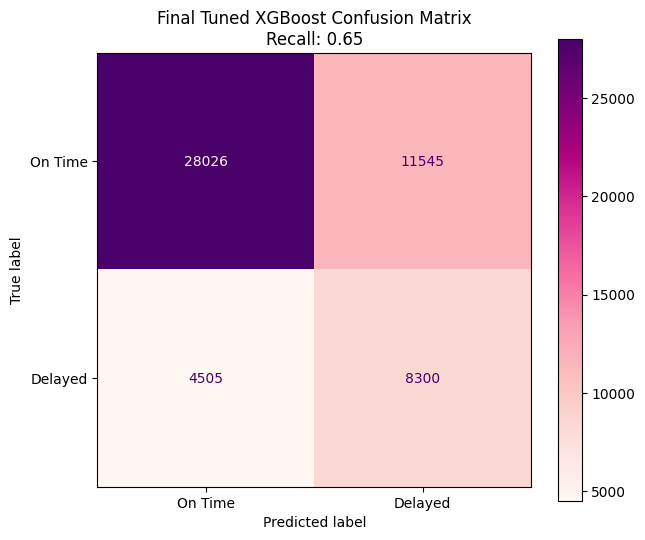

In [731]:
cm = confusion_matrix(validation_labels, final_preds)

# 3. Plot the single matrix
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time', 'Delayed'])

# Using your requested 'RdPu' color scheme
disp.plot(ax=ax, cmap='RdPu', values_format='d')

plt.title(f"Final Tuned XGBoost Confusion Matrix\nRecall: {tuned_recall:.2f}")
plt.show()

C:\Users\lgrun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


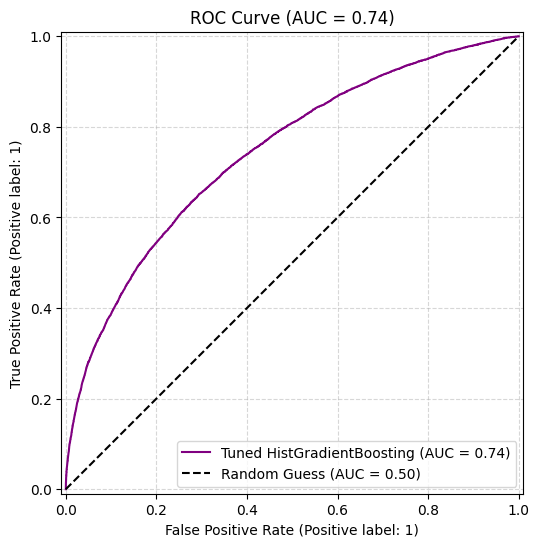

In [733]:
# 1. Get the probability scores for the 'Delayed' class
# Use the validation set to simulate reality
y_score = final_model.predict_proba(prepared_validation_data)[:, 1]

#2. Calculate the ROC-AUC Score
roc_auc = roc_auc_score(validation_labels, y_score)

# 3. Plot the ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
display = RocCurveDisplay.from_predictions(
    validation_labels, 
    y_score, 
    name="Tuned HistGradientBoosting", 
    ax=ax,
    color='purple'
)

# Add the diagonal 0.5 baseline (random guess line)
plt.plot([0, 1], [0, 1], "k--", label="Random Guess (AUC = 0.50)")

ax.set_title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

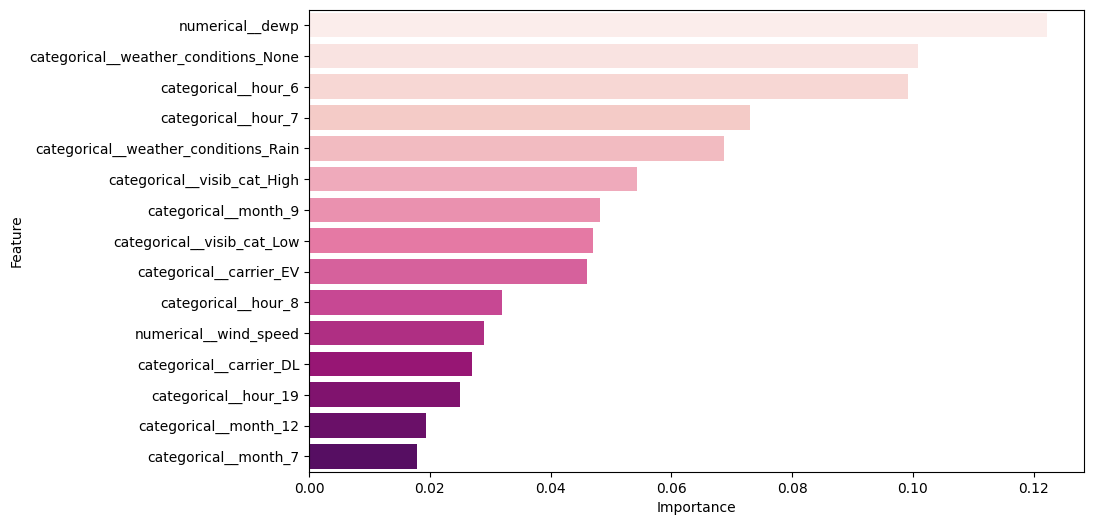

In [734]:
feature_names = full_pipeline.get_feature_names_out()
importances = random_forest_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# print(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(15),
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='RdPu',
    legend=False
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()